# Data Processing Pipeline: From Raw Data to Model‑Ready Features

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook demonstrates a complete data preprocessing pipeline for a customer dataset. It covers data loading, exploratory data analysis, missing value imputation, outlier treatment, categorical encoding, and feature scaling. The pipeline is designed to be modular, reproducible, and ready for machine learning model training.

**Key techniques & libraries:**
- Pandas & NumPy – data manipulation and synthetic data generation
- Scikit‑learn – imputation (`SimpleImputer`), encoding (`OneHotEncoder`, `OrdinalEncoder`), scaling (`StandardScaler`), outlier detection (`IsolationForest`)
- Matplotlib & Seaborn – publication‑quality visualisations

**Data source:**  
A synthetic customer dataset (`clientes_compras_simulado.csv`) is used. If the file is not found, a synthetic dataset with similar characteristics is generated automatically.

In [1]:
# Imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style for publication-quality figures
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14
sns.set_style("whitegrid")

In [2]:
def validate_dataframe(df, name="DataFrame"):
    """
    Print basic validation info for a DataFrame.
    
    Args:
        df (pd.DataFrame): Input DataFrame.
        name (str): Descriptive name for logging.
    """
    print(f"--- {name} Validation ---")
    print(f"Shape: {df.shape}")
    print(f"Column names: {df.columns.tolist()}")
    print(f"Data types:\n{df.dtypes}")
    print(f"Missing values per column:\n{df.isnull().sum()}")
    print(f"First 5 rows:\n{df.head()}")
    print("\n")

def plot_missing_heatmap(df, title="Missing Values Heatmap", figsize=(10, 5)):
    """
    Plot a heatmap of missing values in the DataFrame.
    
    Args:
        df (pd.DataFrame): Input DataFrame.
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def detect_outliers_iqr(series):
    """
    Detect outliers using the Interquartile Range (IQR) method.
    
    Args:
        series (pd.Series): Numeric series.
    
    Returns:
        pd.Series: Boolean mask where True indicates an outlier.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

def plot_histogram_kde(data, column, bins=20, title=None, xlabel=None, figsize=(8, 6)):
    """
    Plot histogram with KDE overlay for a numeric column.
    
    Args:
        data (pd.Series): Numeric data.
        column (str): Column name for labeling.
        bins (int): Number of bins.
        title (str): Plot title.
        xlabel (str): X-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    sns.histplot(data, bins=bins, kde=True, color='blue', alpha=0.6)
    plt.title(title or f"Distribution of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

def plot_boxplot(data, y, x=None, title=None, xlabel=None, ylabel=None, figsize=(8, 6)):
    """
    Plot boxplot for a numeric column, optionally grouped by a categorical column.
    
    Args:
        data (pd.DataFrame): DataFrame containing the data.
        y (str): Numeric column name.
        x (str, optional): Categorical column for grouping.
        title (str): Plot title.
        xlabel (str): X-axis label.
        ylabel (str): Y-axis label.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    if x:
        sns.boxplot(x=x, y=y, data=data, palette="Set2")
    else:
        sns.boxplot(y=y, data=data, palette="Set2")
    plt.title(title or f"Boxplot of {y}")
    plt.xlabel(xlabel or (x if x else ""))
    plt.ylabel(ylabel or y)
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(df, title="Correlation Matrix", figsize=(10, 8)):
    """
    Plot a correlation heatmap for numeric columns.
    
    Args:
        df (pd.DataFrame): DataFrame.
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
# Define file path
data_path = Path("clientes_compras_simulado.csv")

if data_path.exists():
    print(f"Loading data from {data_path}")
    df = pd.read_csv(data_path)
else:
    print(f"File {data_path} not found. Generating synthetic dataset...")
    # Generate synthetic data with similar structure
    np.random.seed(42)
    n = 500
    data = {
        "ID_cliente": [f"C{i+1000}" for i in range(n)],
        "Nombre_cliente": [f"Customer_{i}" for i in range(n)],
        "Edad": np.random.choice(range(18, 80), n),
        "Género": np.random.choice(["M", "F", "Otro"], n, p=[0.45, 0.45, 0.1]),
        "Estado_civil": np.random.choice(["Soltero", "Casado", "Divorciado"], n, p=[0.4, 0.4, 0.2]),
        "Ingreso_anual": np.random.randint(10000, 200000, n),
        "Número_hijos": np.random.choice(range(5), n, p=[0.2, 0.3, 0.25, 0.15, 0.1]),
        "País": np.random.choice(["México", "Argentina", "Colombia", "Chile"], n),
        "Fecha_registro": pd.date_range('2020-01-01', periods=n, freq='D').strftime('%Y-%m-%d'),
        "Frecuencia_compra": np.random.uniform(0, 20, n).round(1),
        "Calificación_satisfacción": np.random.uniform(0, 10, n).round(1),
        "Producto_frecuente": np.random.choice(["Electrónica", "Ropa", "Hogar", "Belleza", "Deportes"], n),
        "Email": [f"user{i}@example.com" for i in range(n)],
        "Descuento_promedio": np.random.randint(0, 100, n),
        "Activo": np.random.choice([0, 1], n, p=[0.5, 0.5]),
        "Código_postal": np.random.randint(1000, 100000, n),
        "Comentarios_cliente": ["Sample comment"] * n,
        "Días_desde_última_compra": np.random.randint(0, 2000, n),
        "Rango_crediticio": np.random.choice(["Bajo", "Medio", "Alto", "Premium"], n),
        "Comprará_de_nuevo": np.random.choice([0, 1], n, p=[0.5, 0.5])
    }
    df = pd.DataFrame(data)

validate_dataframe(df, "Initial Dataset")

File clientes_compras_simulado.csv not found. Generating synthetic dataset...
--- Initial Dataset Validation ---
Shape: (500, 20)
Column names: ['ID_cliente', 'Nombre_cliente', 'Edad', 'Género', 'Estado_civil', 'Ingreso_anual', 'Número_hijos', 'País', 'Fecha_registro', 'Frecuencia_compra', 'Calificación_satisfacción', 'Producto_frecuente', 'Email', 'Descuento_promedio', 'Activo', 'Código_postal', 'Comentarios_cliente', 'Días_desde_última_compra', 'Rango_crediticio', 'Comprará_de_nuevo']
Data types:
ID_cliente                    object
Nombre_cliente                object
Edad                           int64
Género                        object
Estado_civil                  object
Ingreso_anual                  int32
Número_hijos                   int64
País                          object
Fecha_registro                object
Frecuencia_compra            float64
Calificación_satisfacción    float64
Producto_frecuente            object
Email                         object
Descuento_prome

## 1. Data Understanding

We first examine the dataset's structure, summary statistics, and data types to identify potential issues such as missing values, outliers, and irrelevant features.

In [4]:
# Display basic info
print("Dataset Info:")
df.info()

# Summary statistics for numeric columns
print("\nSummary Statistics:")
display(df.describe())

# Show column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_cliente                 500 non-null    object 
 1   Nombre_cliente             500 non-null    object 
 2   Edad                       500 non-null    int64  
 3   Género                     500 non-null    object 
 4   Estado_civil               500 non-null    object 
 5   Ingreso_anual              500 non-null    int32  
 6   Número_hijos               500 non-null    int64  
 7   País                       500 non-null    object 
 8   Fecha_registro             500 non-null    object 
 9   Frecuencia_compra          500 non-null    float64
 10  Calificación_satisfacción  500 non-null    float64
 11  Producto_frecuente         500 non-null    object 
 12  Email                      500 non-null    object 
 13  Descuento_promedio         500 non-n

,Edad,Ingreso_anual,Número_hijos,Frecuencia_compra,Calificación_satisfacción,Descuento_promedio,Activo,Código_postal,Días_desde_última_compra,Comprará_de_nuevo
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,49.910000,107342.160000,1.654000,9.97940,4.978400,47.984000,0.504000,48654.256000,957.480000,0.504000
std,18.221909,54052.392519,1.251165,5.83572,2.825097,28.592075,0.500485,28513.406591,544.243103,0.500485
min,18.000000,10281.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1060.000000,3.000000,0.000000
25%,35.000000,61000.500000,1.000000,5.40000,2.500000,22.000000,0.000000,24002.000000,522.750000,0.000000
50%,50.000000,110614.000000,2.000000,9.75000,5.100000,46.000000,1.000000,47040.500000,936.000000,1.000000
75%,66.000000,155350.500000,3.000000,15.20000,7.300000,72.250000,1.000000,73588.500000,1362.000000,1.000000
max,79.000000,199648.000000,4.000000,20.00000,10.000000,99.000000,1.000000,99970.000000,1996.000000,1.000000



Column names:
['ID_cliente', 'Nombre_cliente', 'Edad', 'Género', 'Estado_civil', 'Ingreso_anual', 'Número_hijos', 'País', 'Fecha_registro', 'Frecuencia_compra', 'Calificación_satisfacción', 'Producto_frecuente', 'Email', 'Descuento_promedio', 'Activo', 'Código_postal', 'Comentarios_cliente', 'Días_desde_última_compra', 'Rango_crediticio', 'Comprará_de_nuevo']


## 2. Feature Selection

We remove columns that are not useful for modelling: identifiers, free‑text comments, and columns with too many unique values or irrelevant information.

In [5]:
# Identify columns to drop
cols_to_drop = [
    'ID_cliente', 'Nombre_cliente', 'Género', 'Estado_civil',
    'Número_hijos', 'Fecha_registro', 'Email', 'Código_postal',
    'Comentarios_cliente'
]
# Keep only if they exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

validate_dataframe(df, "After Dropping Useless Columns")

--- After Dropping Useless Columns Validation ---
Shape: (500, 11)
Column names: ['Edad', 'Ingreso_anual', 'País', 'Frecuencia_compra', 'Calificación_satisfacción', 'Producto_frecuente', 'Descuento_promedio', 'Activo', 'Días_desde_última_compra', 'Rango_crediticio', 'Comprará_de_nuevo']
Data types:
Edad                           int64
Ingreso_anual                  int32
País                          object
Frecuencia_compra            float64
Calificación_satisfacción    float64
Producto_frecuente            object
Descuento_promedio             int32
Activo                         int64
Días_desde_última_compra       int32
Rango_crediticio              object
Comprará_de_nuevo              int64
dtype: object
Missing values per column:
Edad                         0
Ingreso_anual                0
País                         0
Frecuencia_compra            0
Calificación_satisfacción    0
Producto_frecuente           0
Descuento_promedio           0
Activo                       0
Días

## 3. Missing Value Analysis

We visualise missing values and compute the percentage of missing data per column. This informs our imputation strategy.

Missing percentage per column:
Edad                         0.0
Ingreso_anual                0.0
País                         0.0
Frecuencia_compra            0.0
Calificación_satisfacción    0.0
Producto_frecuente           0.0
Descuento_promedio           0.0
Activo                       0.0
Días_desde_última_compra     0.0
Rango_crediticio             0.0
Comprará_de_nuevo            0.0
dtype: float64


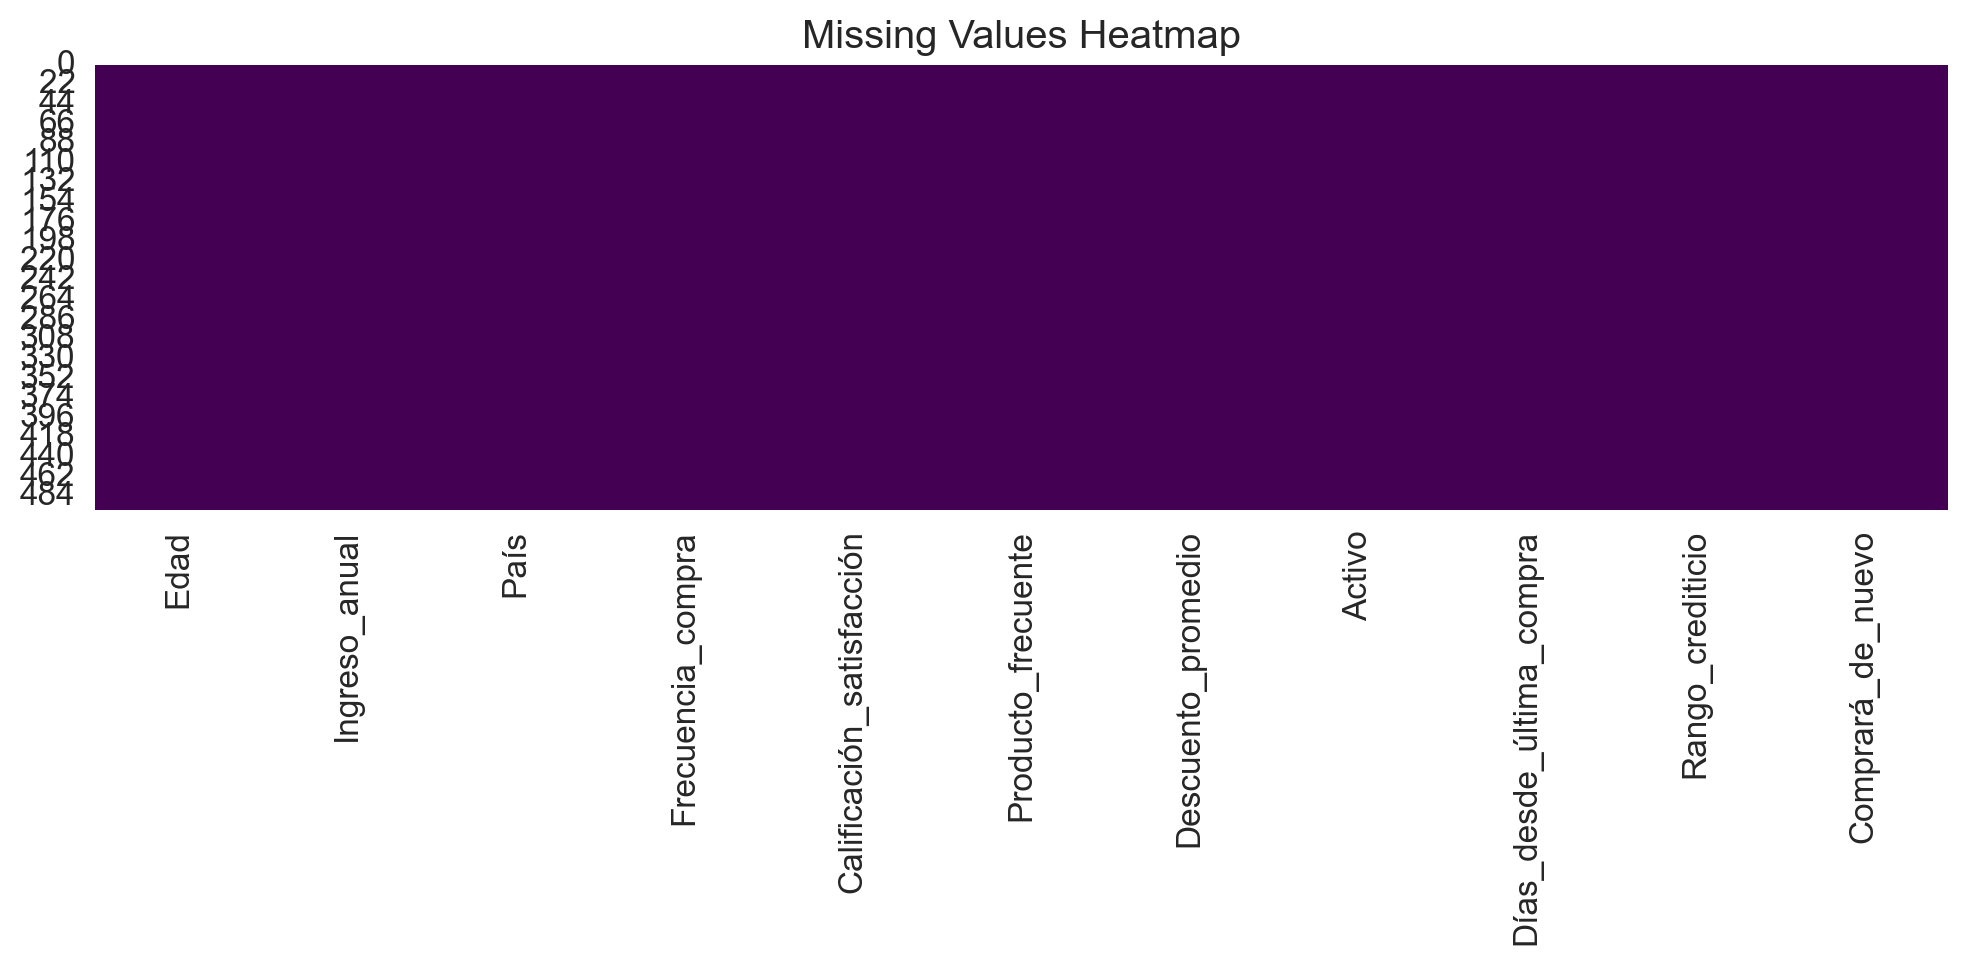

In [6]:
# Missing percentage
missing_pct = df.isnull().mean() * 100
print("Missing percentage per column:")
print(missing_pct)

# Heatmap
plot_missing_heatmap(df, "Missing Values Heatmap")

## 4. Exploratory Data Analysis and Outlier Detection

We visualise the distribution of numeric features, detect outliers using boxplots and the IQR method, and also use Isolation Forest for multivariate outlier detection.

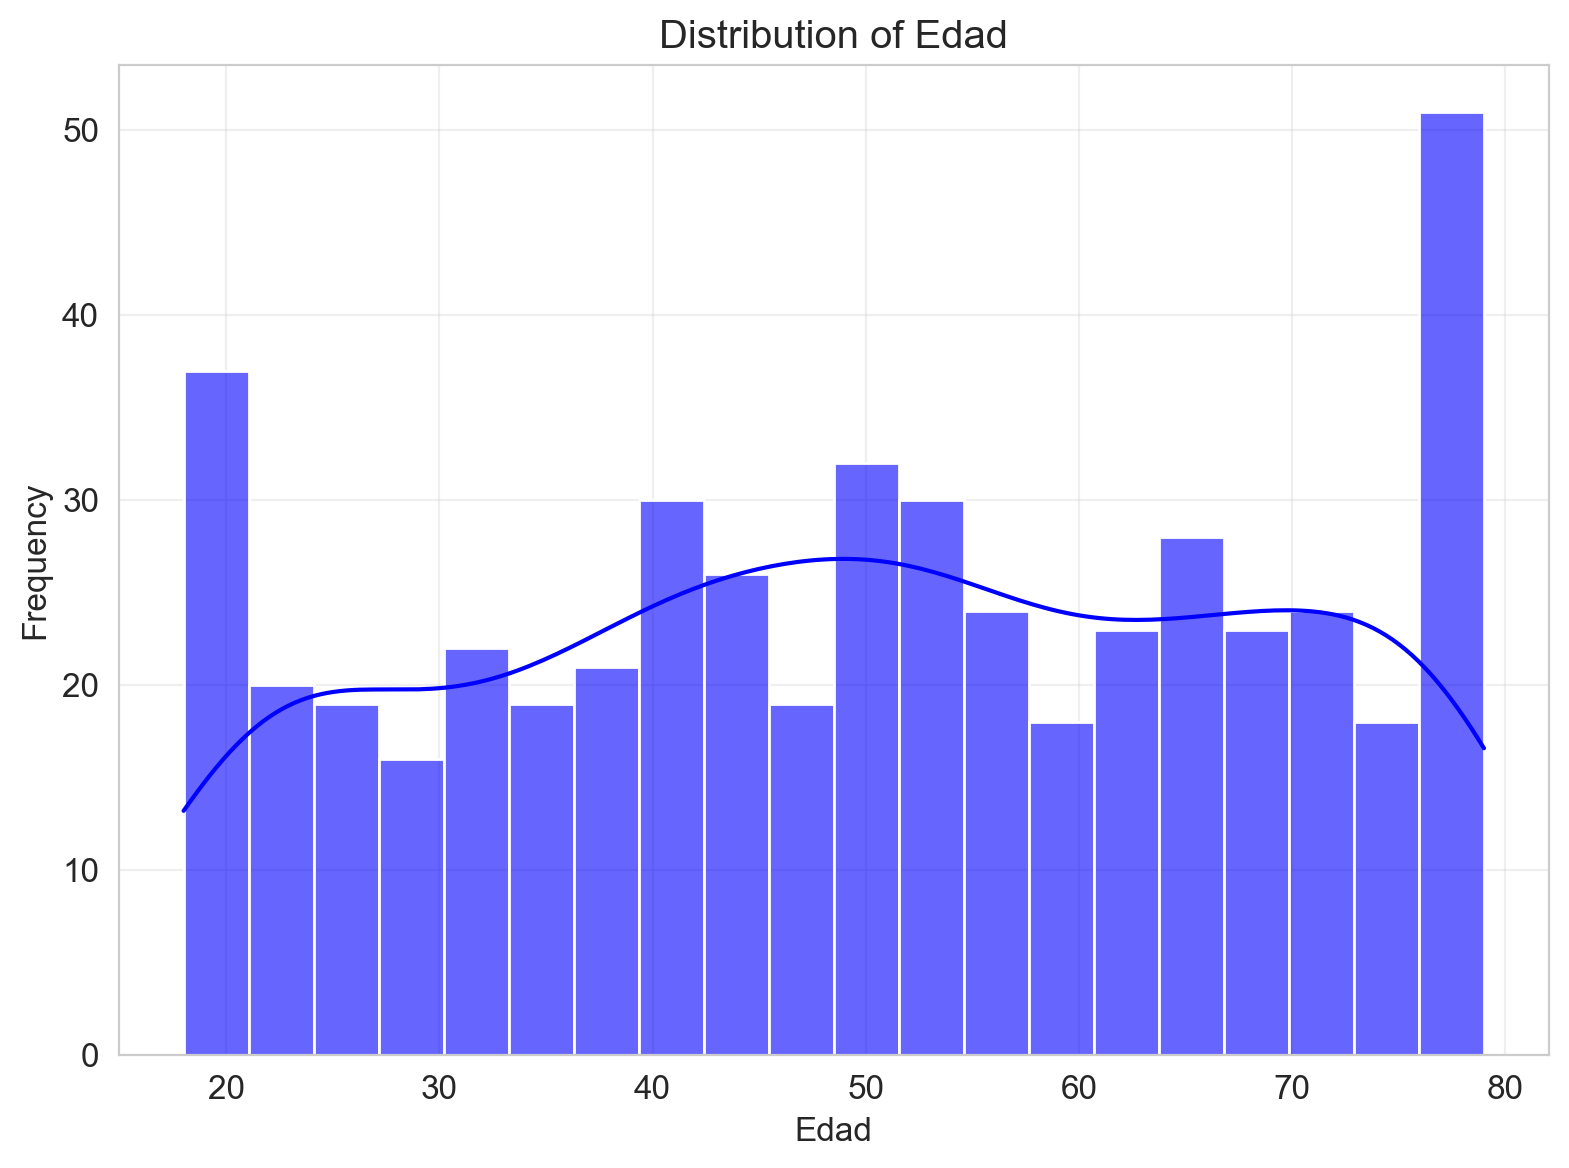

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


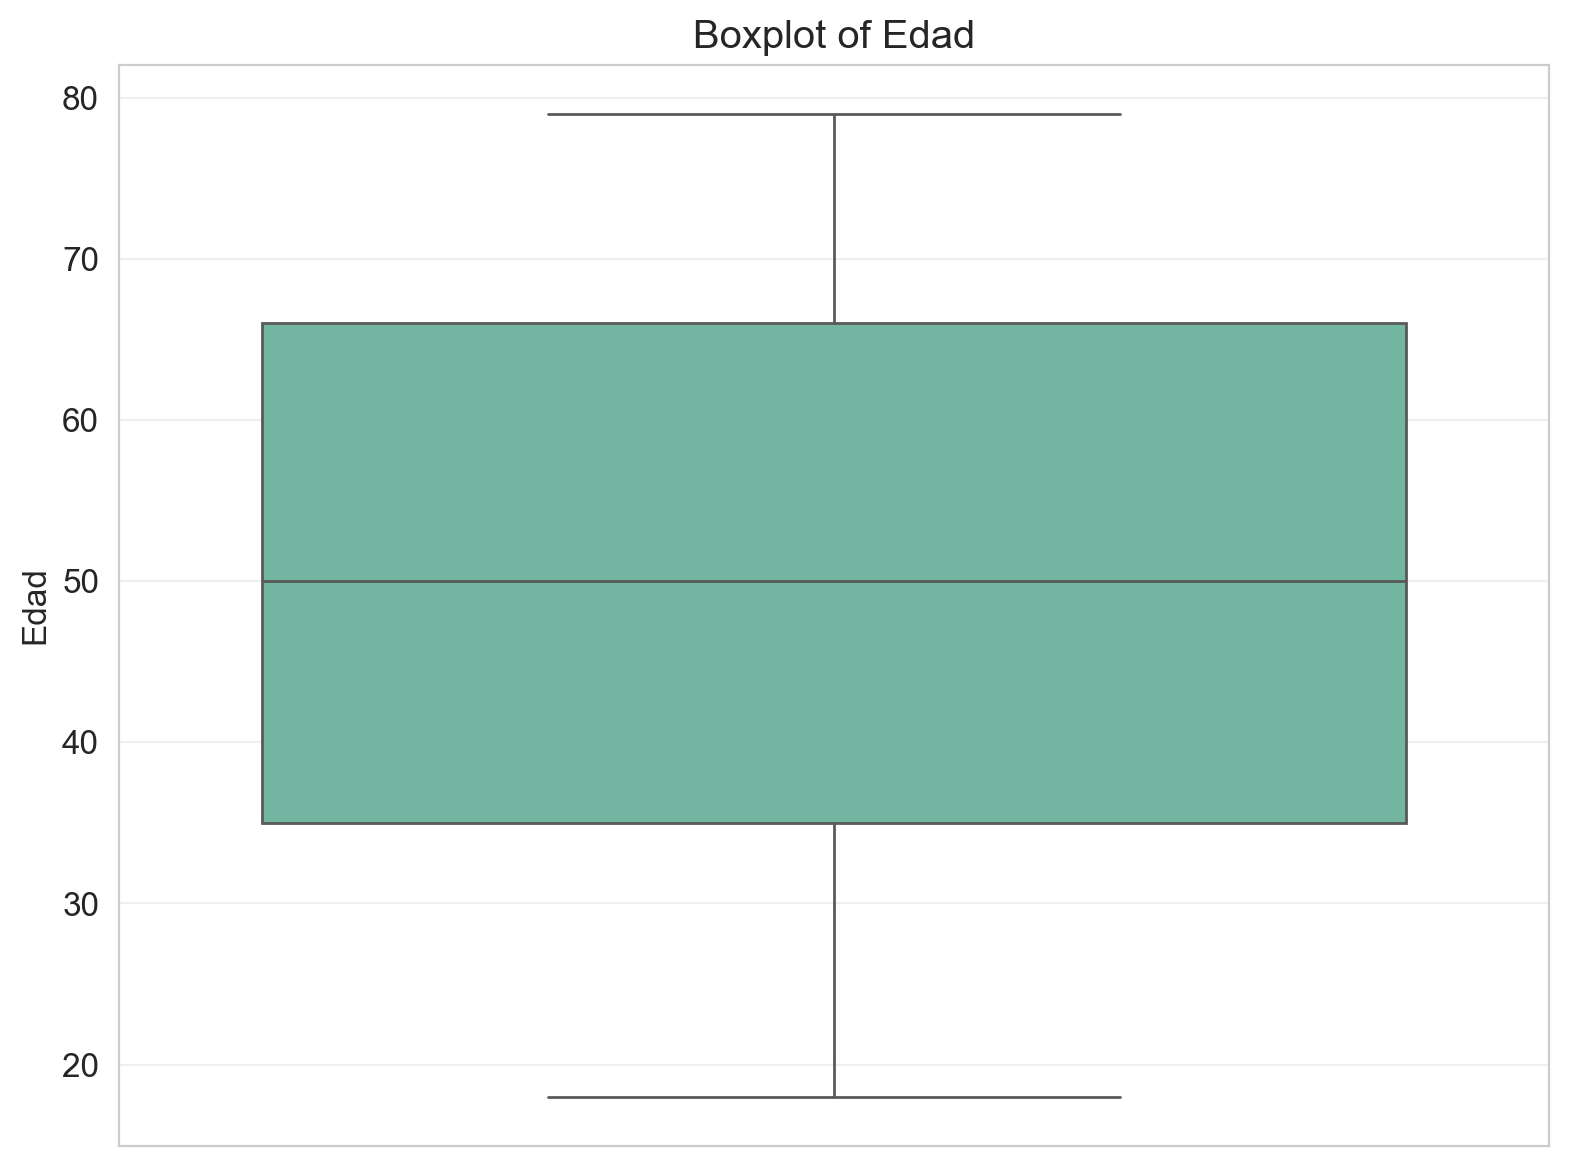

No outliers in Edad


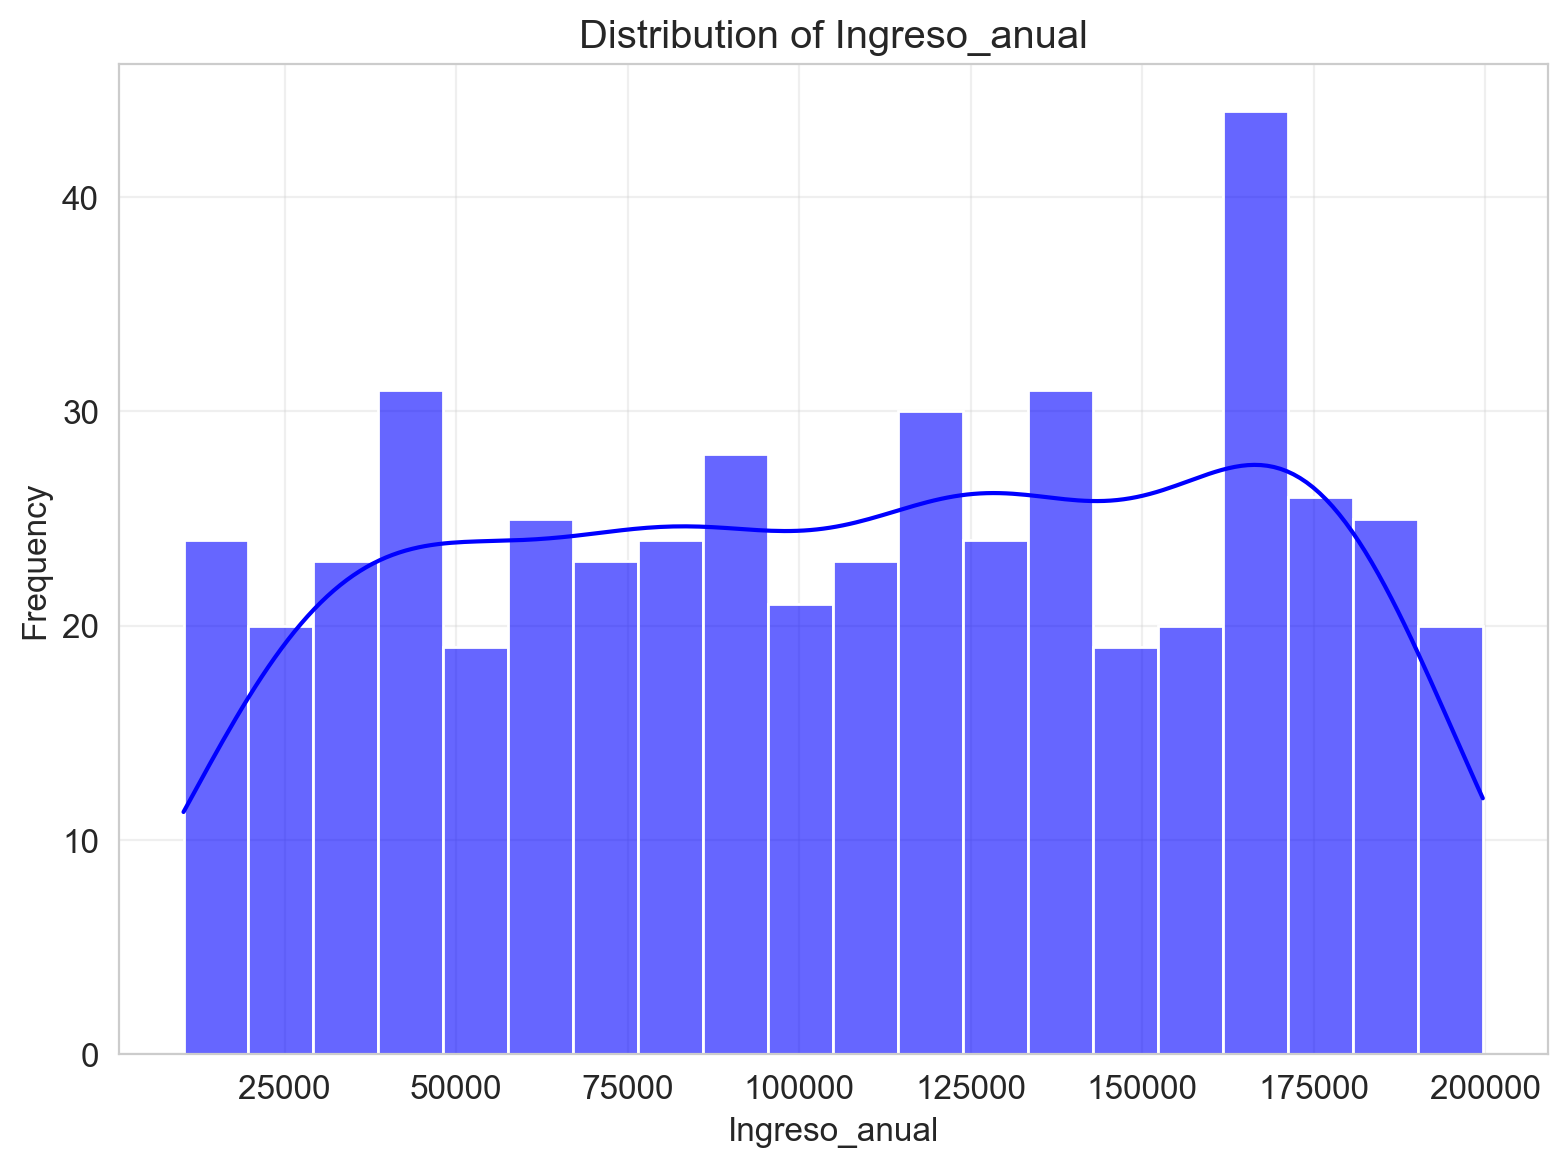

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


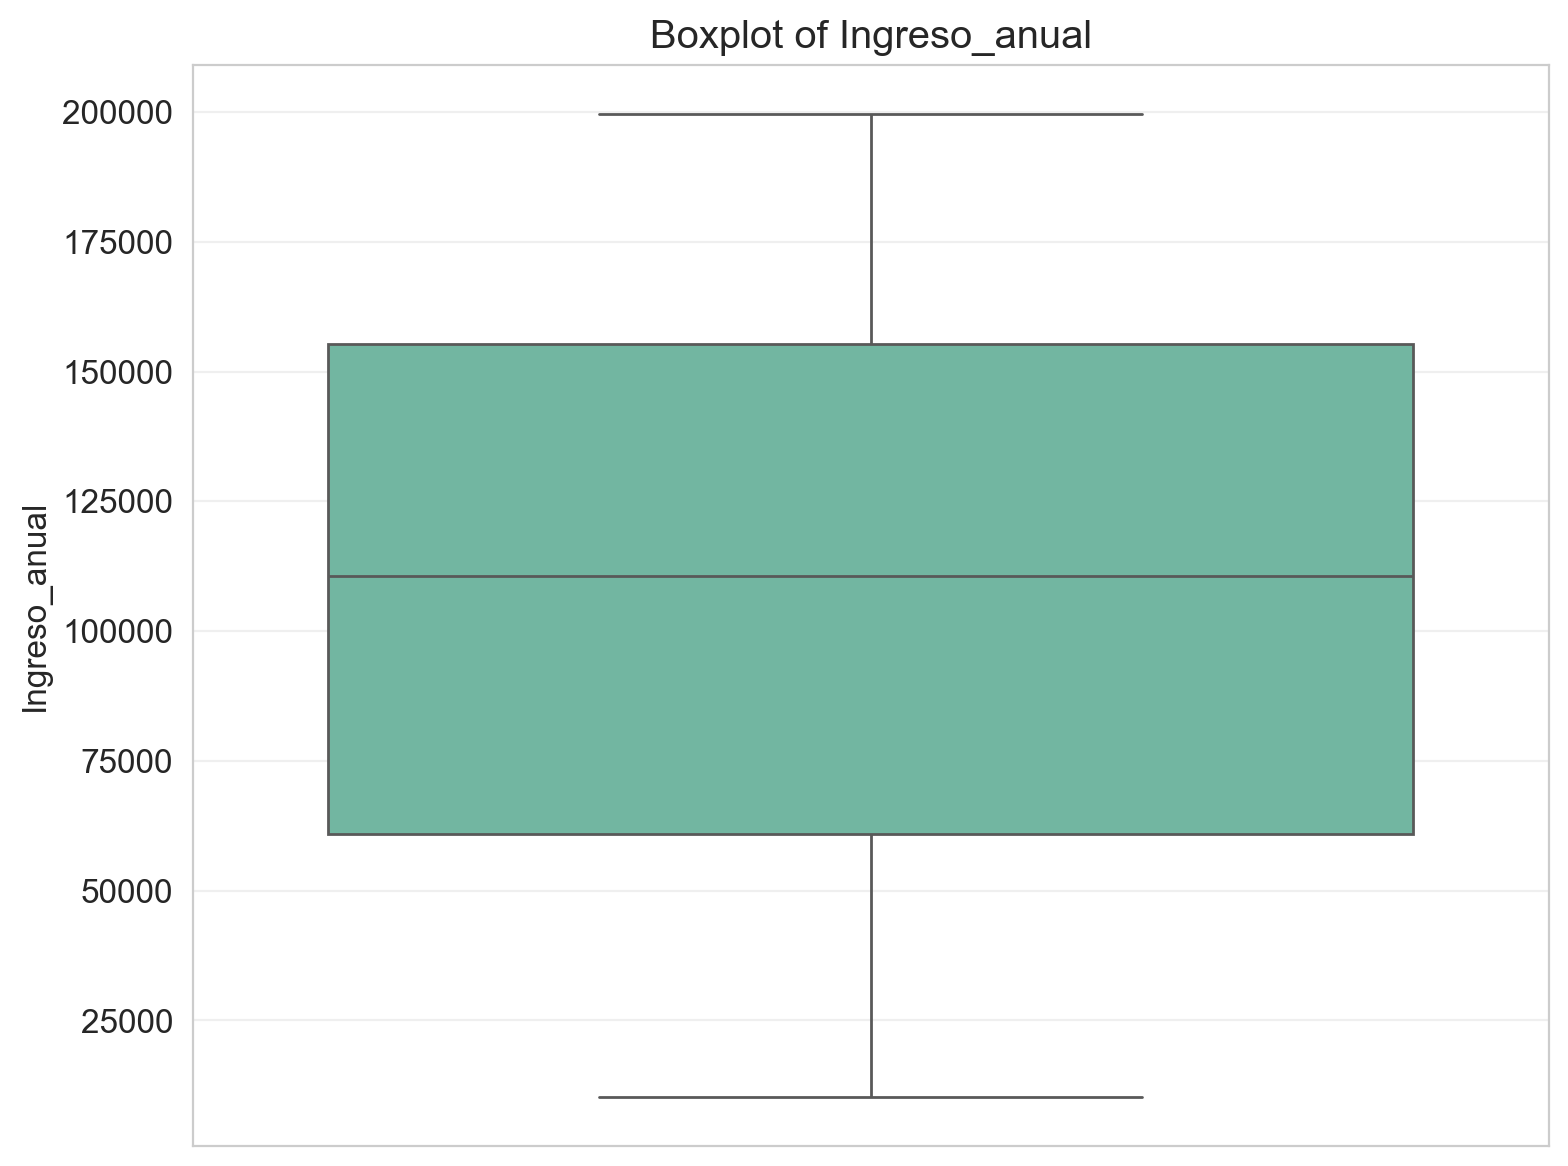

No outliers in Ingreso_anual


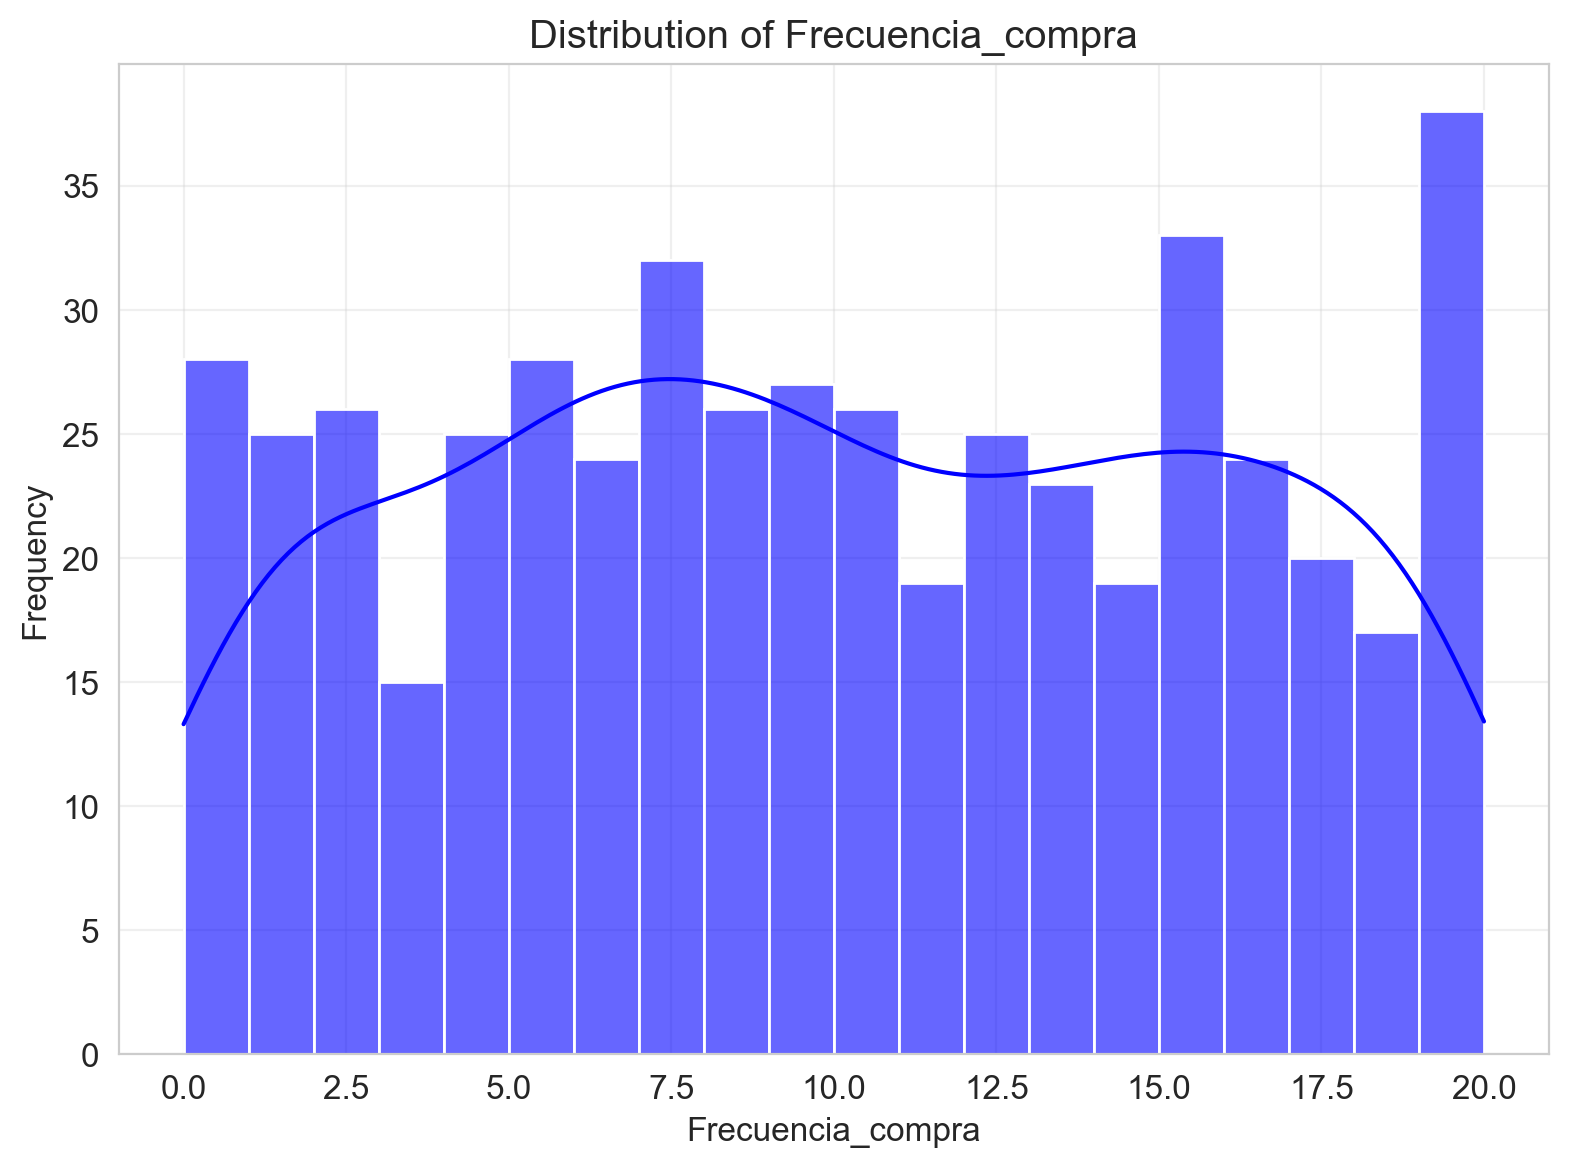

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


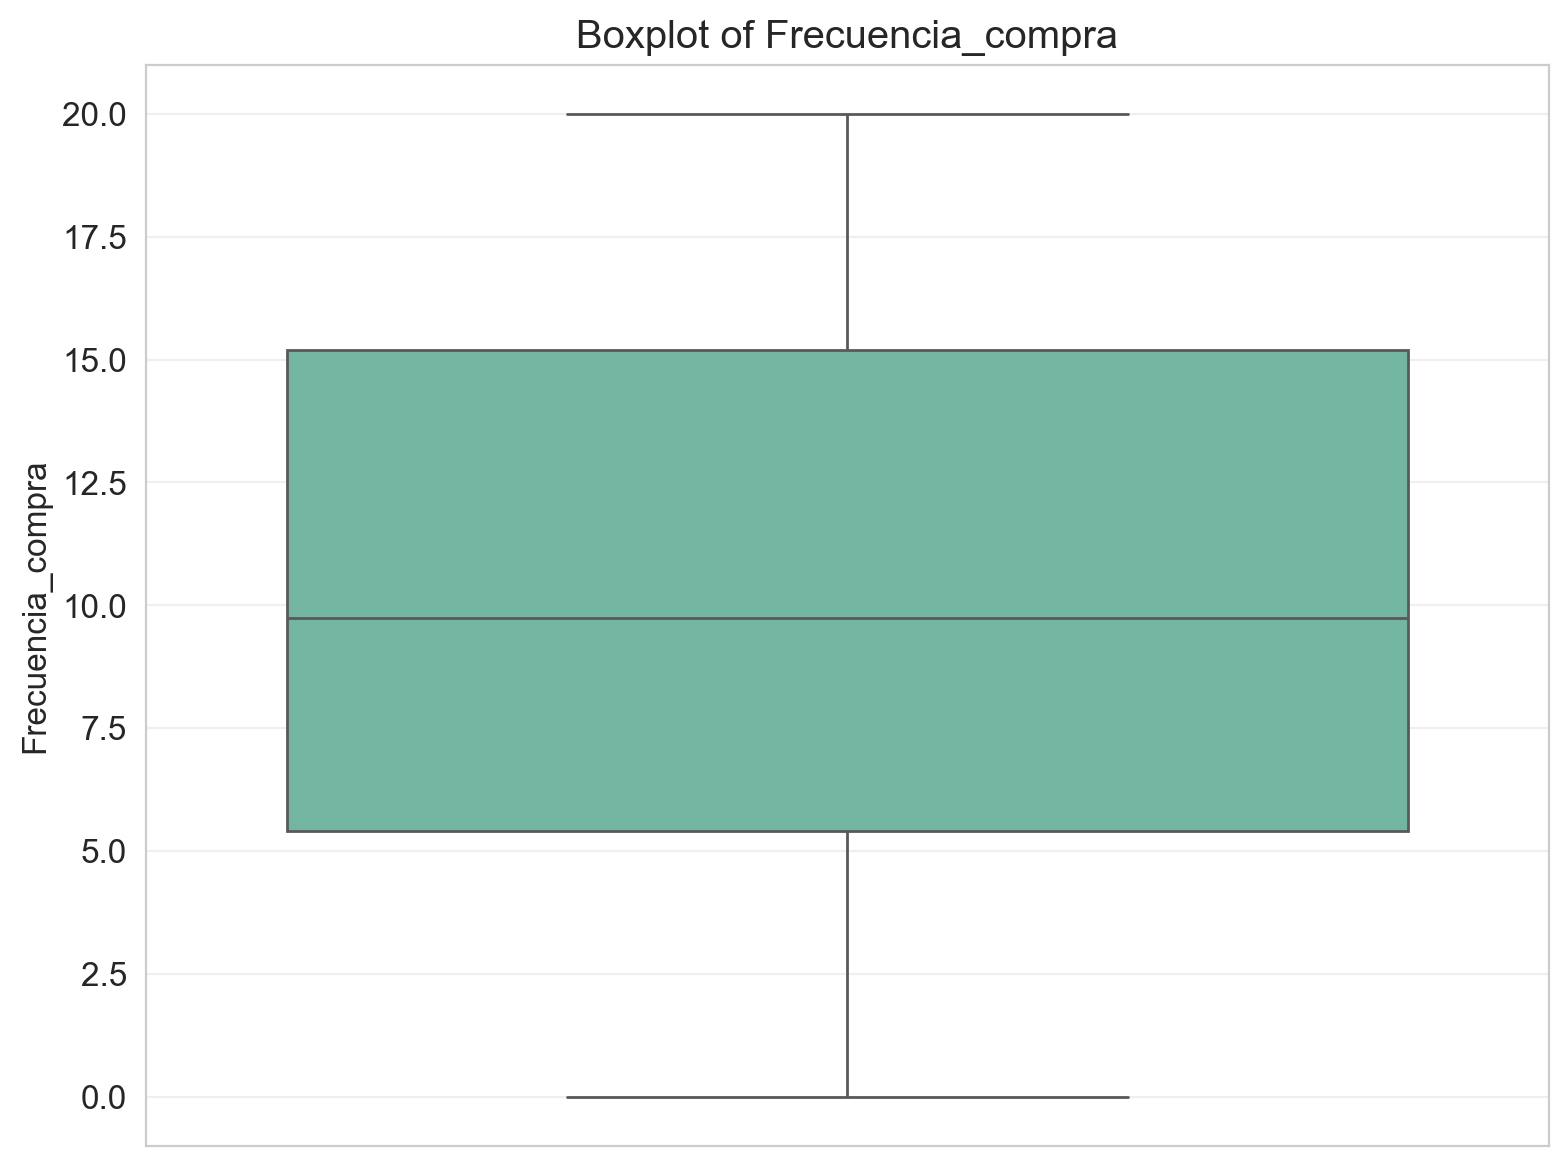

No outliers in Frecuencia_compra


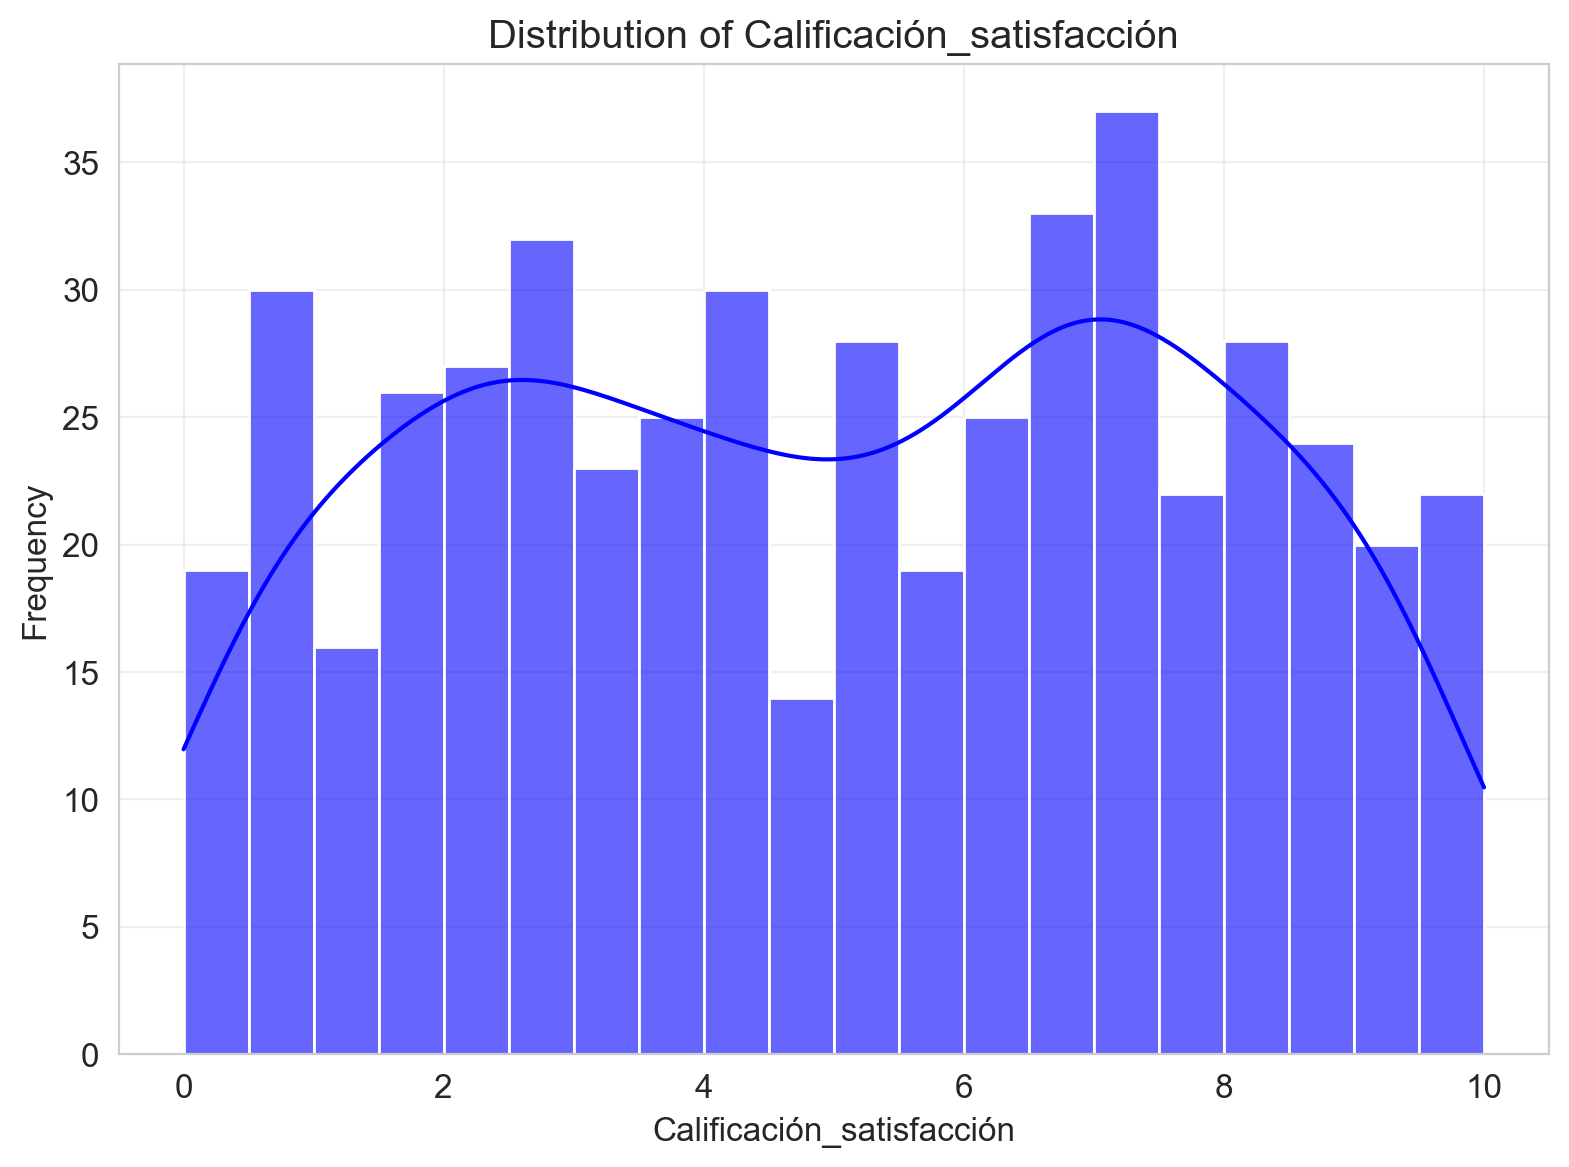

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


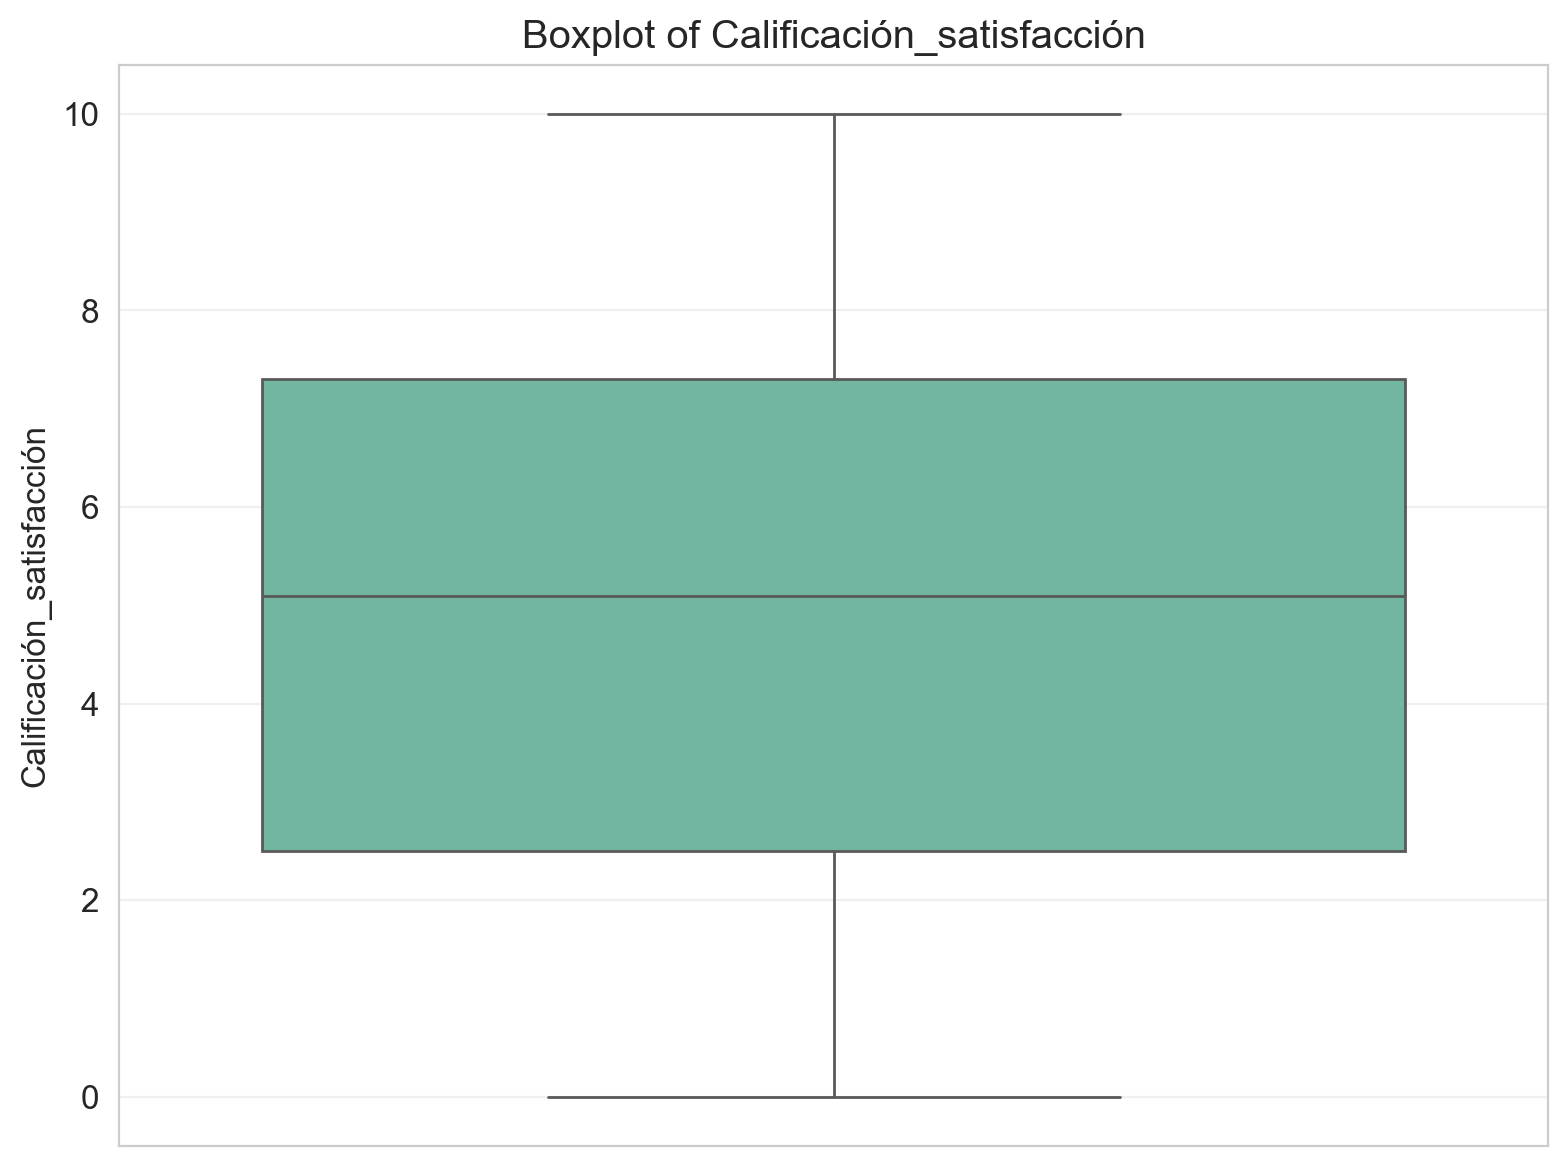

No outliers in Calificación_satisfacción


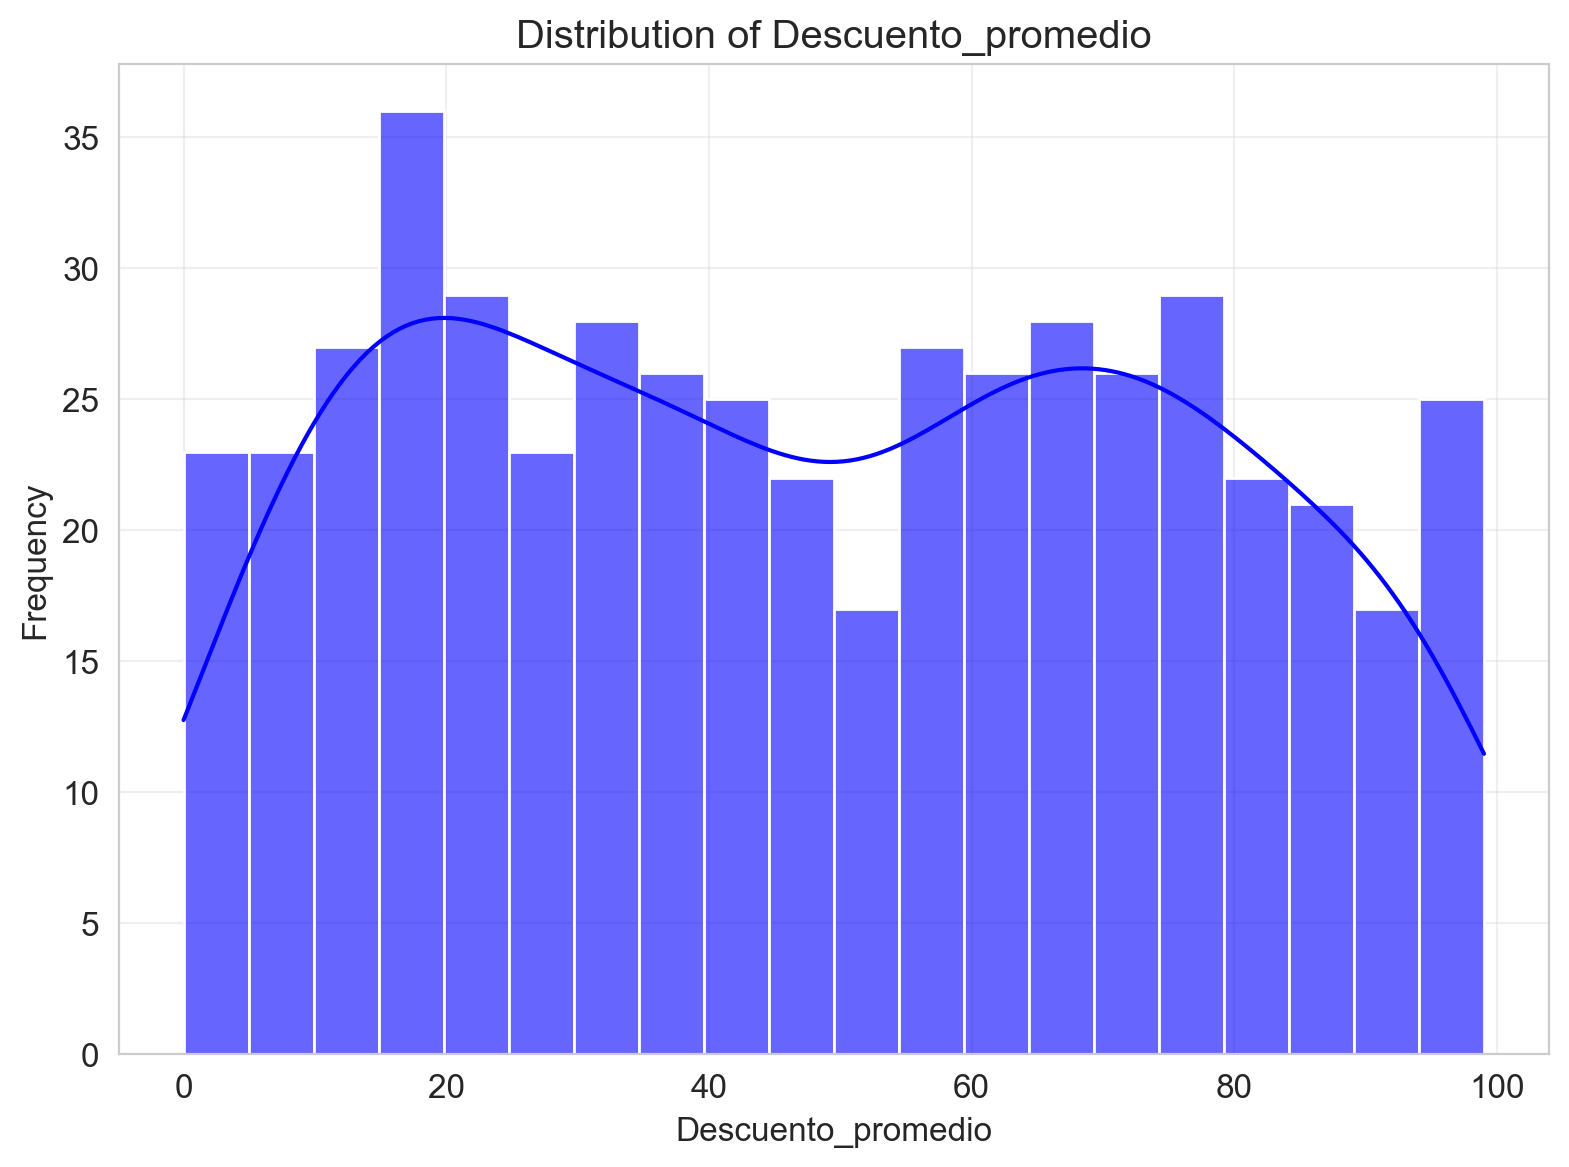

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


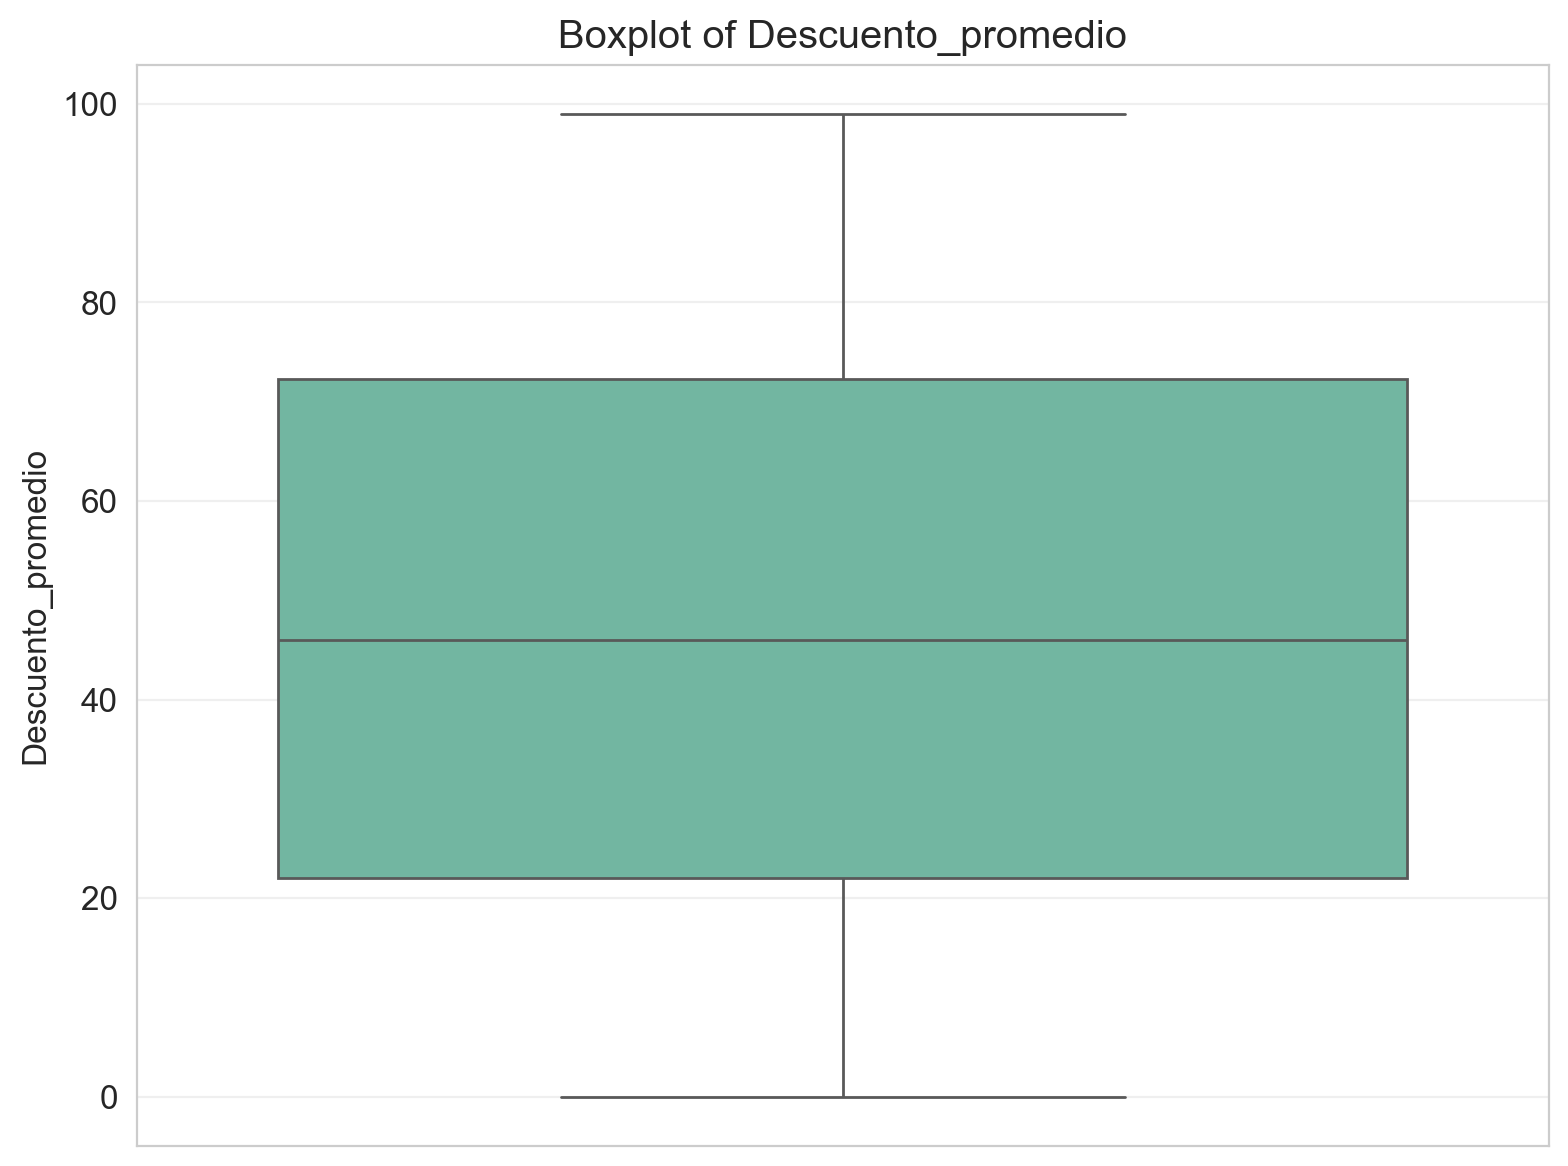

No outliers in Descuento_promedio


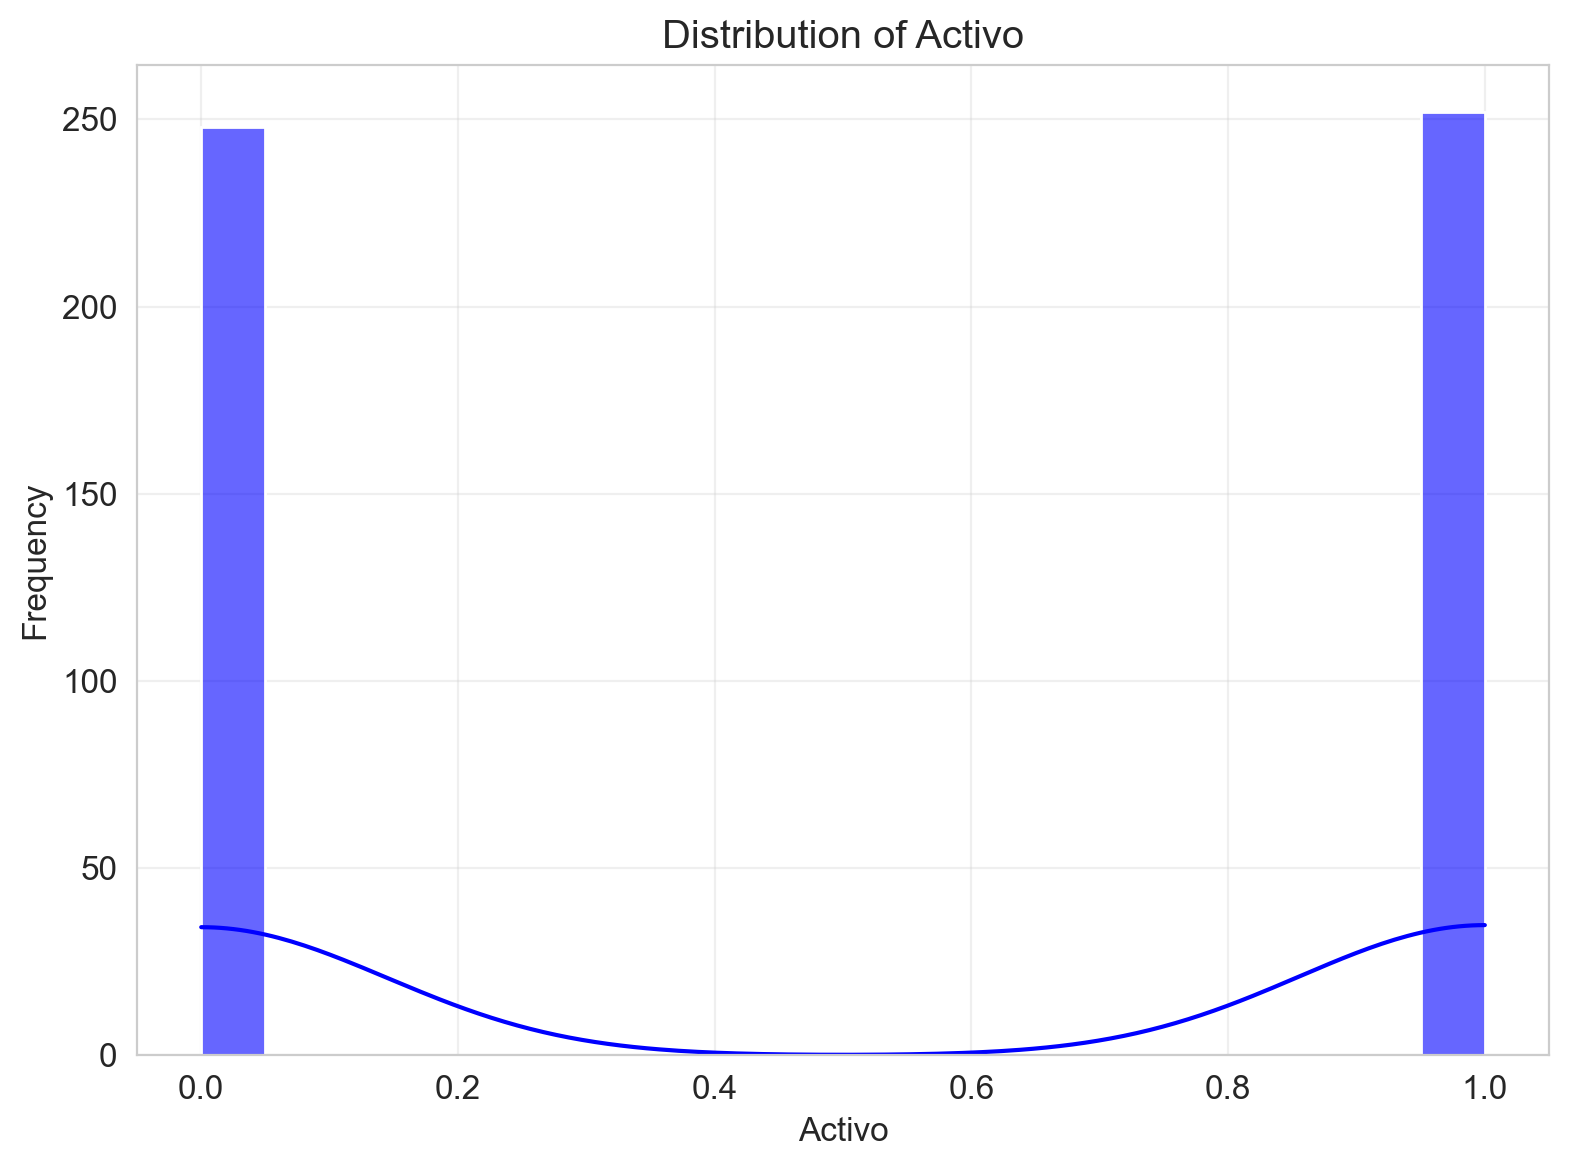

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


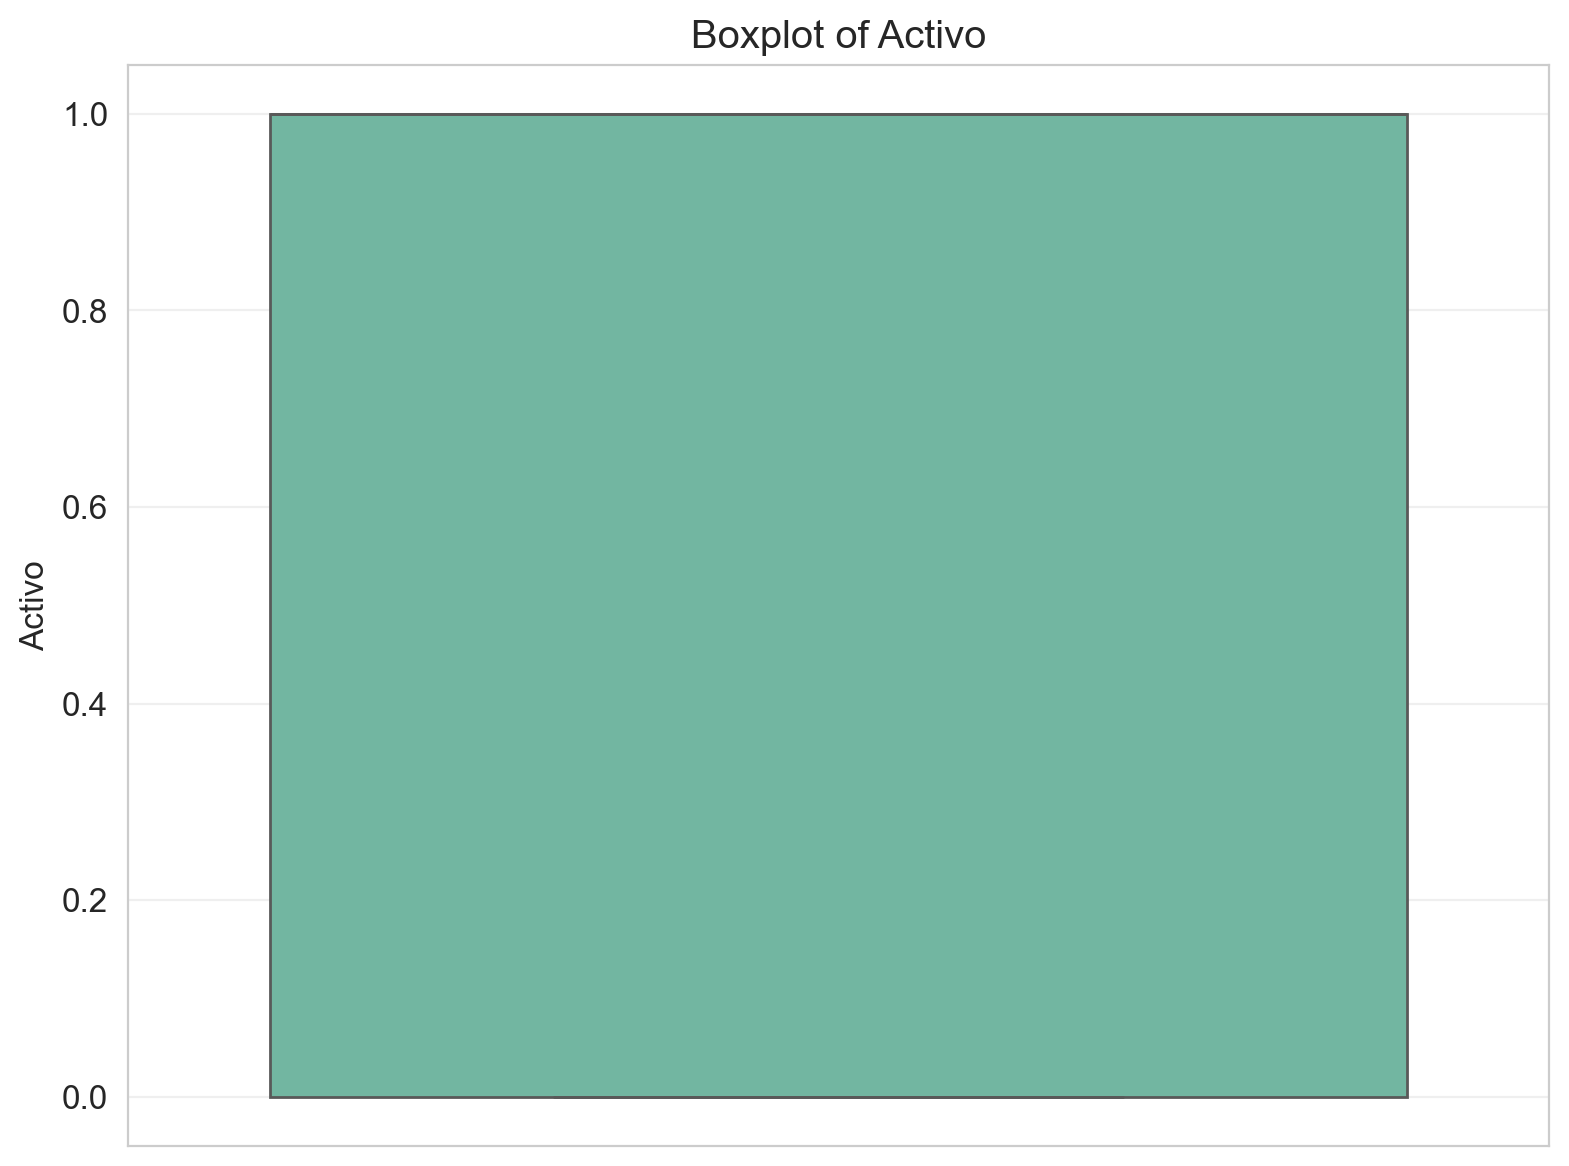

No outliers in Activo


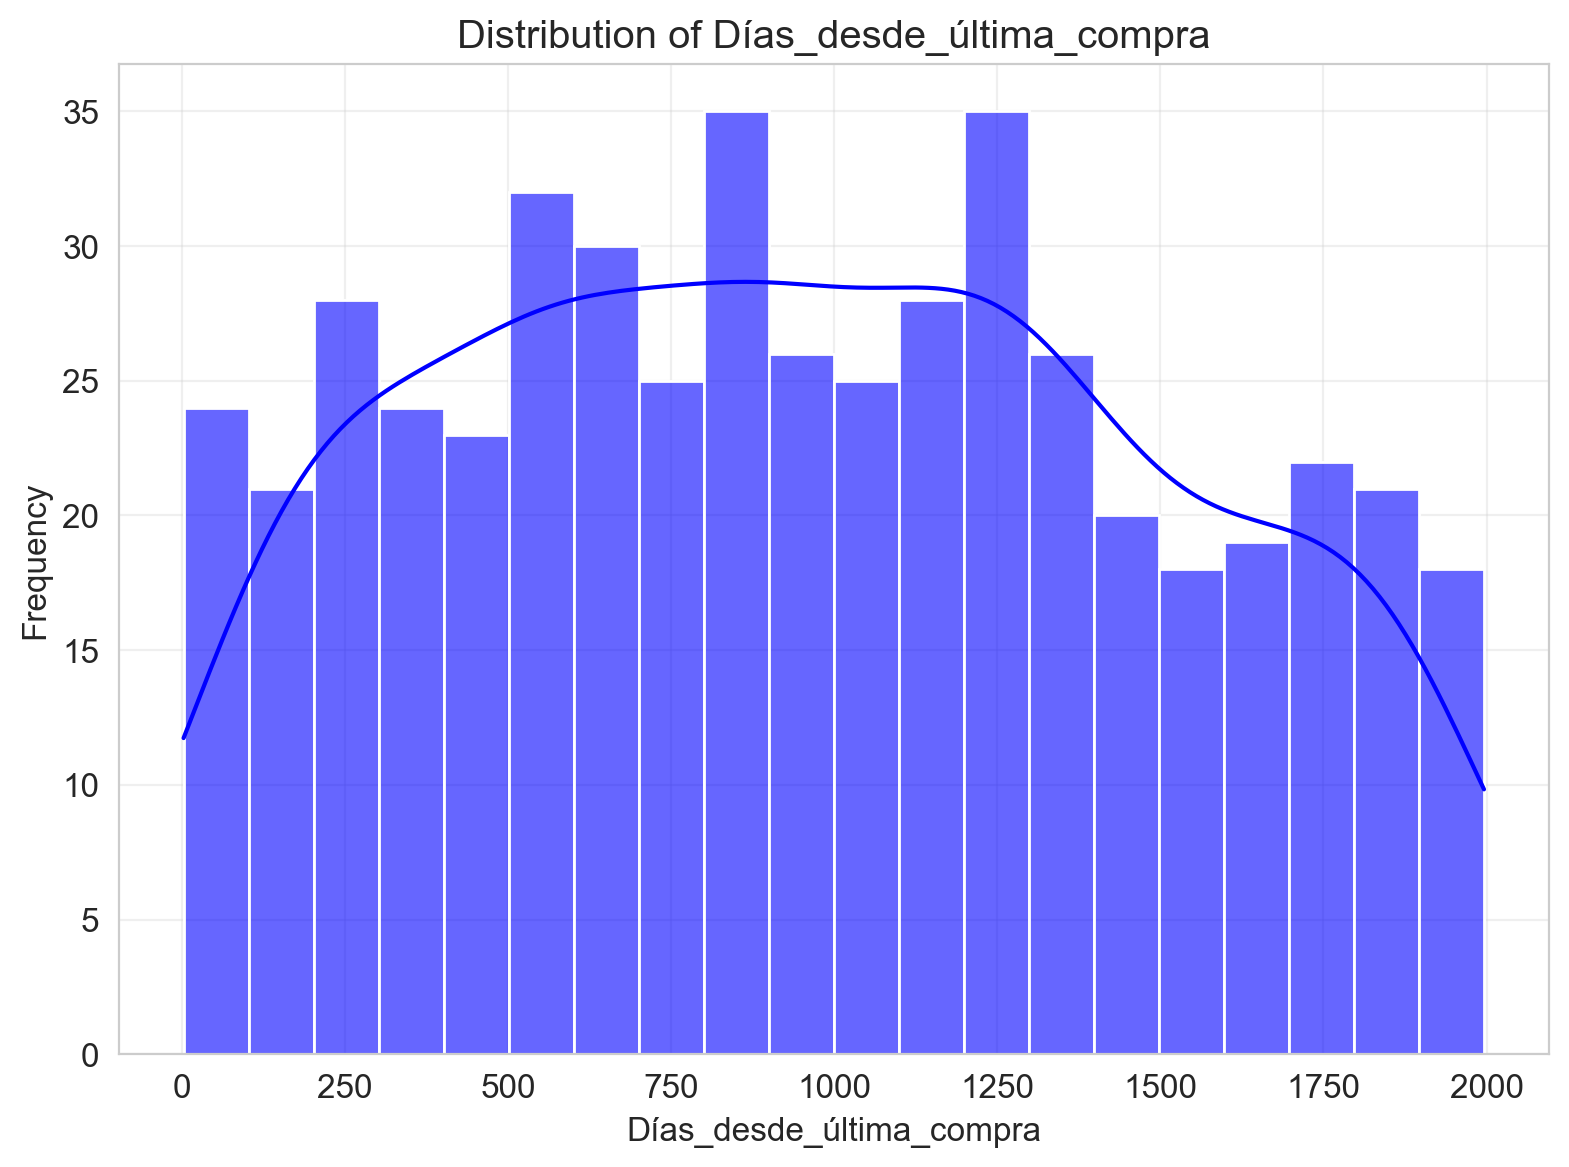

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


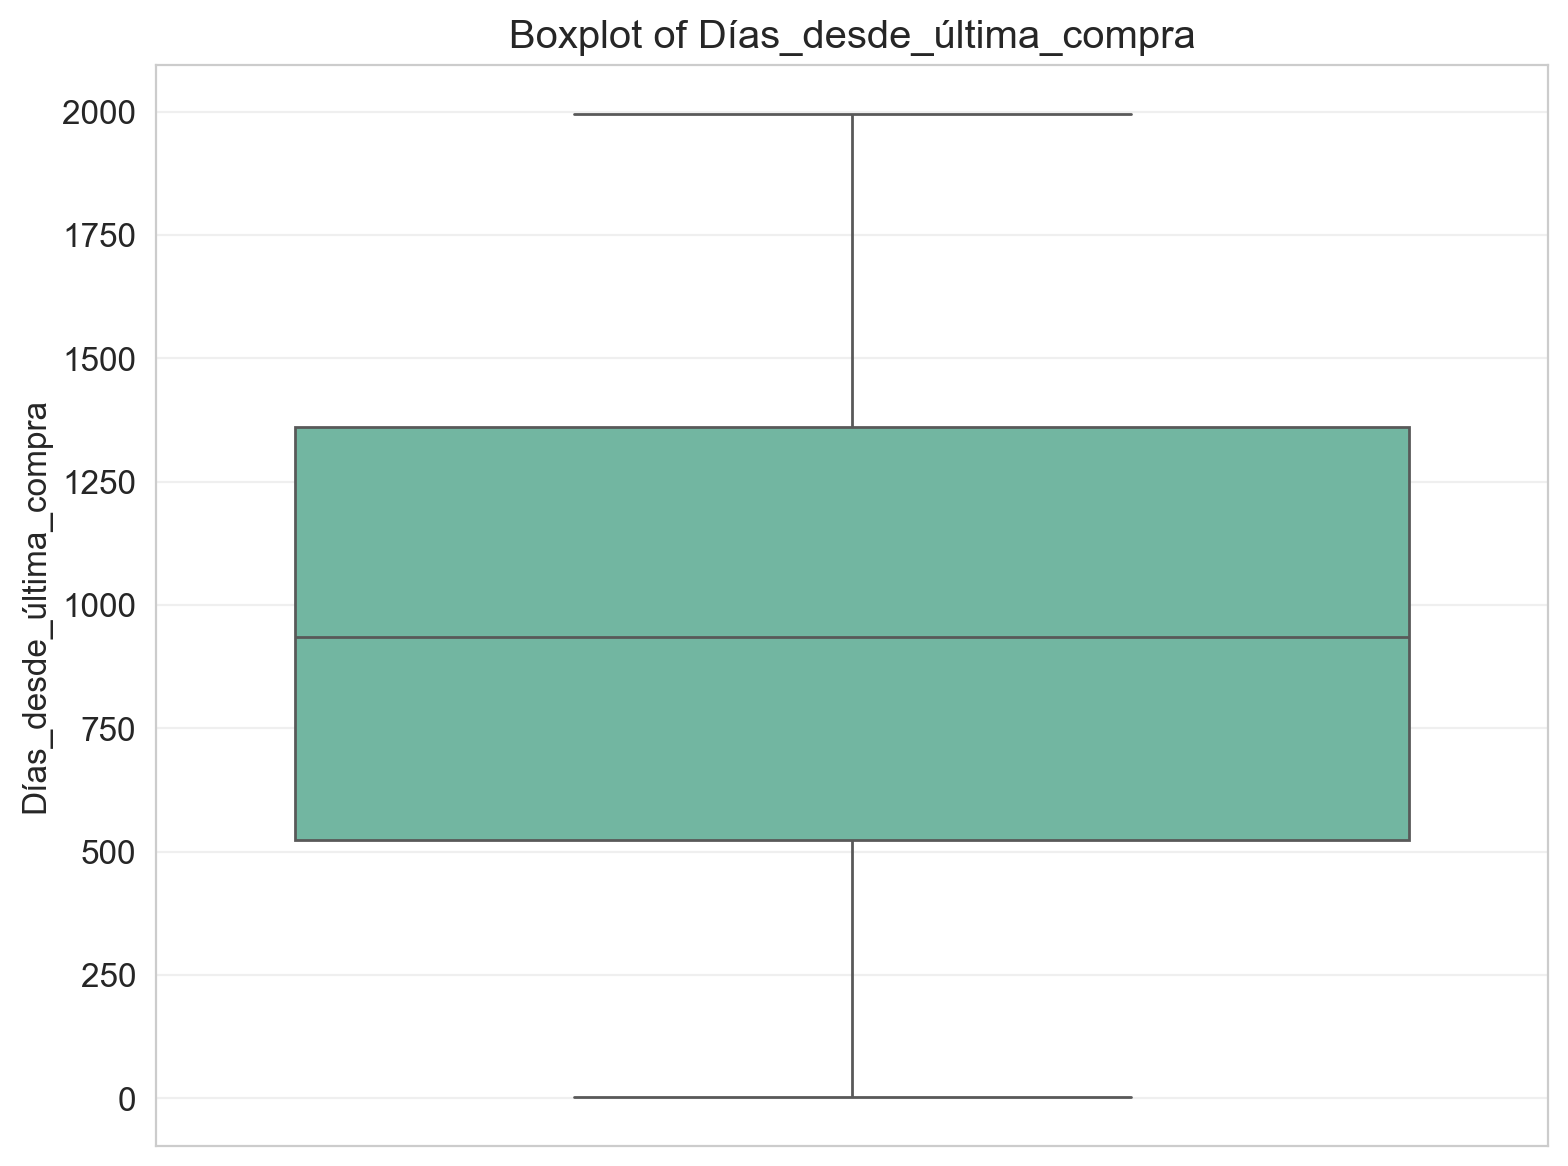

No outliers in Días_desde_última_compra


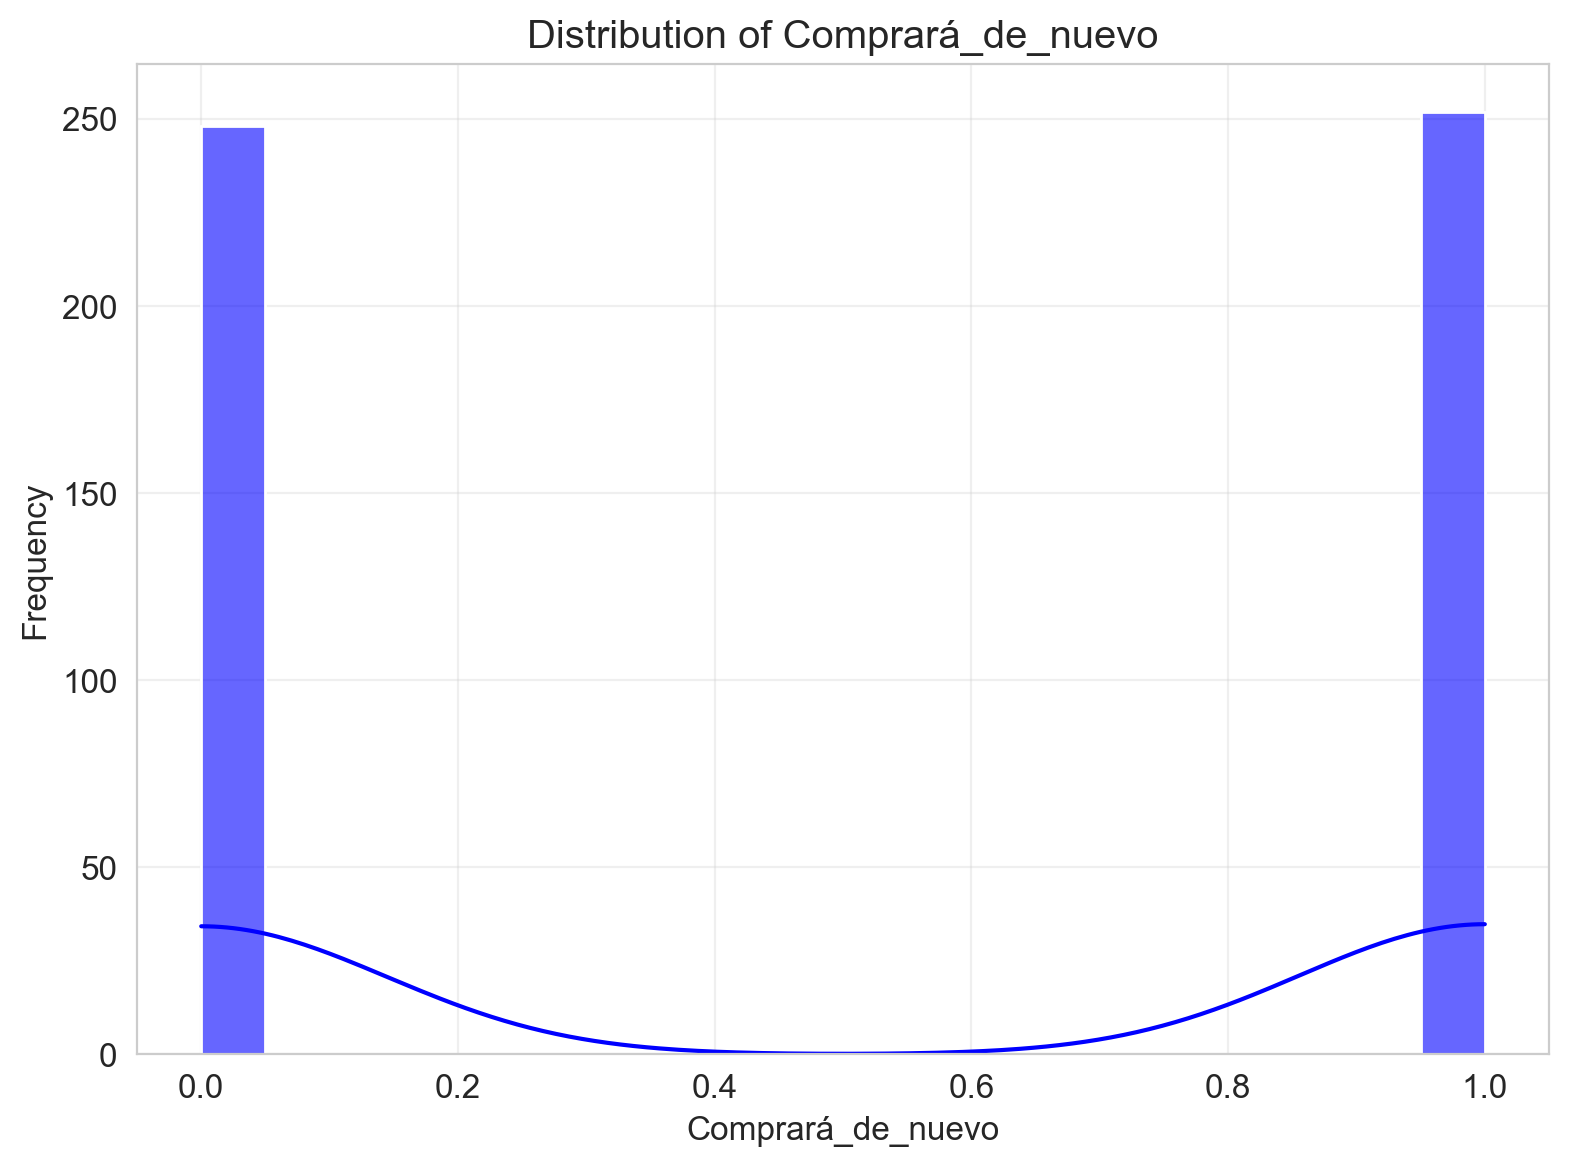

C:\Users\phabe\AppData\Local\Temp\ipykernel_44508\3559316216.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=y, data=data, palette="Set2")


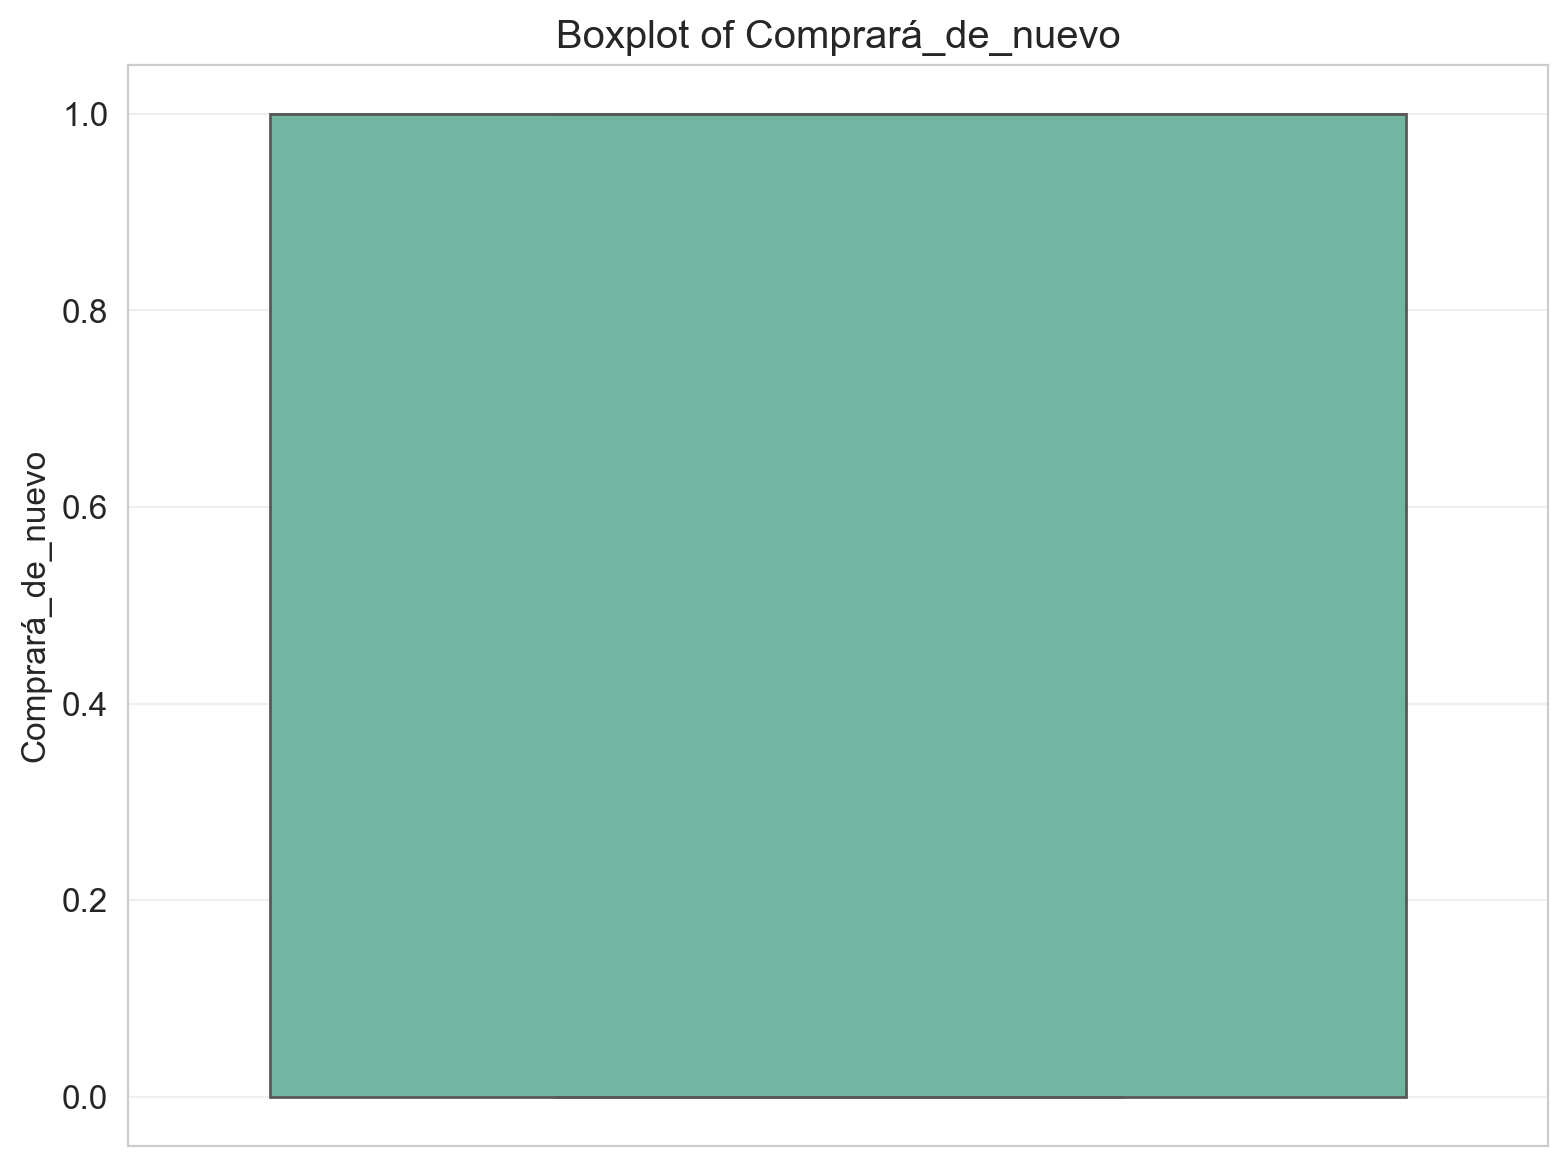

No outliers in Comprará_de_nuevo
Columns with outliers: []
Outliers detected by Isolation Forest: [32, 48, 51, 68, 102, 115, 139, 196, 221, 241, 243, 245, 262, 266, 271, 273, 333, 335, 338, 347, 366, 381, 407, 421, 452]


In [7]:
# Identify numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_columns = []

for feature in num_cols:
    # Histogram with KDE
    plot_histogram_kde(df[feature], feature, title=f"Distribution of {feature}")
    
    # Boxplot
    plot_boxplot(df, y=feature, title=f"Boxplot of {feature}")
    
    # IQR outlier detection
    outliers_mask = detect_outliers_iqr(df[feature])
    outliers = df[outliers_mask]
    if not outliers.empty:
        outlier_columns.append(feature)
        print(f"Outliers in {feature}: {outliers.index.tolist()}")
        print(outliers[[feature]].head())
    else:
        print(f"No outliers in {feature}")

print(f"Columns with outliers: {outlier_columns}")

# Optional: Isolation Forest for multivariate outliers
if len(num_cols) > 1:
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    df['Outlier_IF'] = iso_forest.fit_predict(df[num_cols])
    outliers_if = df.index[df['Outlier_IF'] == -1].tolist()
    print(f"Outliers detected by Isolation Forest: {outliers_if}")
    # Drop the temporary column
    df.drop(columns=['Outlier_IF'], inplace=True)

## 5. Missing Value Imputation

We impute missing values using appropriate strategies:
- **Mean imputation** for numeric columns (after handling outliers by capping or setting to NaN).
- **Most frequent imputation** for categorical columns.
- We first treat extreme outliers by capping them to the IQR bounds or setting to NaN.

In [8]:
# Cap outliers using IQR method (replace with NaN or clip)
for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Clip outliers to bounds (or set to NaN)
    df[col] = df[col].clip(lower, upper)

# Impute missing values
# Numeric columns: mean imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
imputer_mean = SimpleImputer(strategy='mean')
df[numeric_cols] = imputer_mean.fit_transform(df[numeric_cols])

# Categorical columns: most frequent imputation
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
imputer_mode = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_mode.fit_transform(df[cat_cols])

# Verify no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum().sum())

Missing values after imputation:
0


## 6. Correlation Analysis

We compute and visualise the correlation matrix to understand relationships between numeric features.

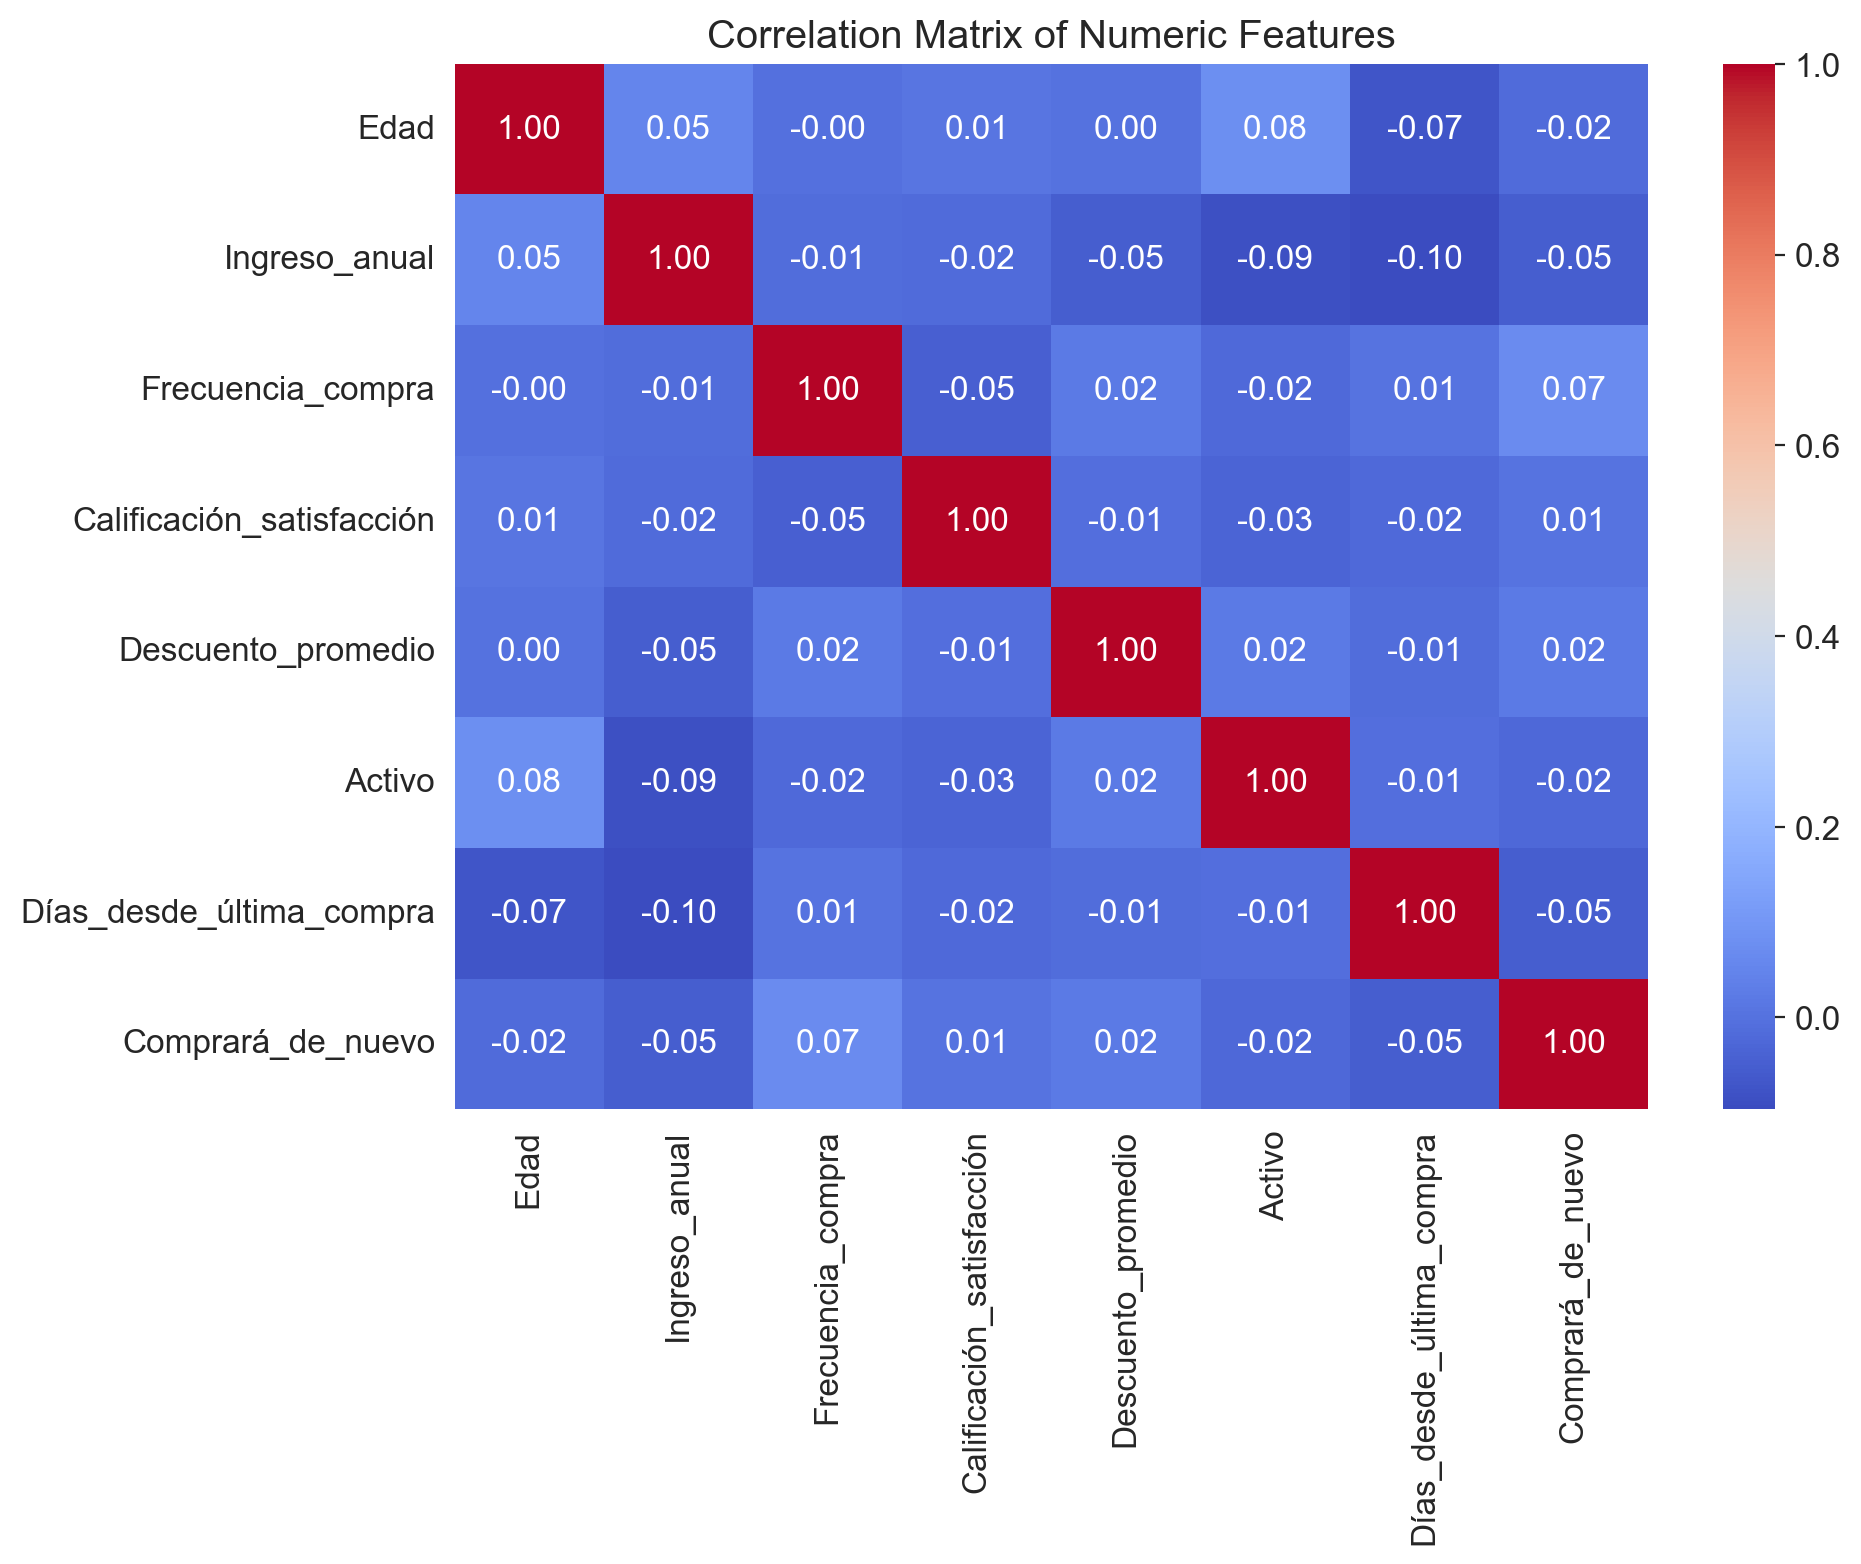

In [9]:
plot_correlation_heatmap(df, "Correlation Matrix of Numeric Features")

## 7. Categorical Encoding

We encode categorical variables using:
- **One‑Hot Encoding** for nominal categories (País, Producto_frecuente)
- **Ordinal Encoding** for ordered categories (Rango_crediticio)

In [10]:
# One-Hot Encoding for País
ohe = OneHotEncoder(sparse_output=False, drop='first')
pais_encoded = ohe.fit_transform(df[['País']])
pais_cols = ohe.get_feature_names_out(['País'])
df_pais = pd.DataFrame(pais_encoded, columns=pais_cols, index=df.index)
df = pd.concat([df.drop(columns=['País']), df_pais], axis=1)

# One-Hot Encoding for Producto_frecuente
ohe = OneHotEncoder(sparse_output=False, drop='first')
prod_encoded = ohe.fit_transform(df[['Producto_frecuente']])
prod_cols = ohe.get_feature_names_out(['Producto_frecuente'])
df_prod = pd.DataFrame(prod_encoded, columns=prod_cols, index=df.index)
df = pd.concat([df.drop(columns=['Producto_frecuente']), df_prod], axis=1)

# Ordinal Encoding for Rango_crediticio (Bajo, Medio, Alto, Premium)
ord_enc = OrdinalEncoder(categories=[['Bajo', 'Medio', 'Alto', 'Premium']])
df['Rango_crediticio'] = ord_enc.fit_transform(df[['Rango_crediticio']])

# Check resulting columns
print("Encoded DataFrame columns:")
print(df.columns.tolist())

Encoded DataFrame columns:
['Edad', 'Ingreso_anual', 'Frecuencia_compra', 'Calificación_satisfacción', 'Descuento_promedio', 'Activo', 'Días_desde_última_compra', 'Rango_crediticio', 'Comprará_de_nuevo', 'País_Chile', 'País_Colombia', 'País_México', 'Producto_frecuente_Deportes', 'Producto_frecuente_Electrónica', 'Producto_frecuente_Hogar', 'Producto_frecuente_Ropa']


## 8. Feature Scaling

We standardise numeric features to have zero mean and unit variance, which is beneficial for many machine learning algorithms.

In [11]:
# Select numeric columns to scale (exclude binary and encoded columns)
scale_cols = ['Edad', 'Ingreso_anual', 'Frecuencia_compra',
              'Calificación_satisfacción', 'Descuento_promedio',
              'Días_desde_última_compra']

# Ensure only existing columns
scale_cols = [col for col in scale_cols if col in df.columns]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# Show final processed data
validate_dataframe(df, "Final Processed Data")

--- Final Processed Data Validation ---
Shape: (500, 16)
Column names: ['Edad', 'Ingreso_anual', 'Frecuencia_compra', 'Calificación_satisfacción', 'Descuento_promedio', 'Activo', 'Días_desde_última_compra', 'Rango_crediticio', 'Comprará_de_nuevo', 'País_Chile', 'País_Colombia', 'País_México', 'Producto_frecuente_Deportes', 'Producto_frecuente_Electrónica', 'Producto_frecuente_Hogar', 'Producto_frecuente_Ropa']
Data types:
Edad                              float64
Ingreso_anual                     float64
Frecuencia_compra                 float64
Calificación_satisfacción         float64
Descuento_promedio                float64
Activo                            float64
Días_desde_última_compra          float64
Rango_crediticio                  float64
Comprará_de_nuevo                 float64
País_Chile                        float64
País_Colombia                     float64
País_México                       float64
Producto_frecuente_Deportes       float64
Producto_frecuente_Electróni

## Summary and Next Steps

**Accomplished in this notebook:**

- Loaded and, if necessary, generated a synthetic customer dataset.
- Performed data understanding (info, summary statistics, column inspection).
- Dropped irrelevant columns (IDs, free‑text, dates, etc.).
- Visualised missing values and imputed them using mean (numeric) and mode (categorical) strategies.
- Detected and treated outliers using IQR capping and Isolation Forest.
- Analysed feature correlations.
- Encoded categorical variables (one‑hot and ordinal).
- Standardised numeric features to prepare for machine learning.

**Key insights:**

- The dataset contains several numeric and categorical features with moderate correlations.
- Outliers were present in some numeric columns; capping them improved robustness.
- Imputation and encoding make the dataset ready for model training.

**Suggested next steps (critical thinking):**

1. **Feature engineering** – create new features (e.g., recency, frequency, monetary value) from existing ones to improve model performance.
2. **Dimensionality reduction** – apply PCA or feature selection to reduce noise and multicollinearity.
3. **Model training** – use the processed dataset to train classification or regression models and evaluate performance.
4. **Automated pipeline** – wrap the entire preprocessing into a scikit‑learn `Pipeline` with `ColumnTransformer` for production use.
5. **Data versioning** – track changes to the dataset and pipeline for reproducibility.